In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

In [3]:
def show_mean(dim : int, filename : str) -> None:
    """
    Muestra la media de hitting time en función del tamaño del espacio.
    
    Parámetros:
    - dim (int): Dimensión del espacio.
    - filename (str): Nombre del archivo CSV.
    """

    df = pd.read_csv(f"../data/{filename}")
    df = df[df["Dimension"] == f"{dim}D"]
    return df

In [4]:
def get_data(dimension, filename):

    df = pd.read_csv(f"../data/{filename}")
    df = df[df["Dimension"] == f"{dimension}D"]
    df.columns = df.columns.str.strip()
    
    return list(df.itertuples(index = False, name = None))

In [7]:
def plot_hitting_time(data):
    """
    Genera un gráfico del Hitting Time, su dispersión (STD) y el valor máximo
    en función del Size dentro de una misma dimensión.

    Parámetros:
    - data (list of tuples): Lista de tuplas con (Dimension, Size, Mean Hitting, STD, Max).
    """
    # Extraer datos por separado
    sizes = np.array([row[1] for row in data])  # Segundo elemento: Size
    mean_hitting = np.array([row[2] for row in data])  # Tercer elemento: Mean Hitting
    std_hitting = np.array([row[3] for row in data])  # Cuarto elemento: STD
    max_hitting = np.array([row[4] for row in data])  # Quinto elemento: Max

    # Obtener la dimensión
    dimension_label = f"{data[0][0]}"  # Extrae la primera dimensión de los datos

    # Calcular la multiplicidad (Max / Mean)
    multiplicidad = max_hitting / mean_hitting

    # Crear la figura con fondo uniforme
    fig, ax = plt.subplots(figsize=(22, 12))
    fig.patch.set_facecolor("#f8f8f8")  # Fondo general del gráfico
    ax.set_facecolor("#f0f0f0")  # Fondo del área de la gráfica

    # Gráfico del Hitting Time con barras de error (STD)
    ax.errorbar(sizes, mean_hitting, yerr=std_hitting, fmt='o-', color='blue', linewidth=2, markersize=8, label="Hitting Time (±STD)")

    # Gráfico del valor máximo de hitting time
    ax.fill_between(sizes, mean_hitting - std_hitting, mean_hitting + std_hitting, color='blue', alpha=0.2)
    ax.plot(sizes, max_hitting, linestyle="--", marker="s", color="red", linewidth=2, markersize=8, label="Max")

    # Agregar etiquetas de los valores en cada punto
    for x, y1, y2, m in zip(sizes, mean_hitting, max_hitting, multiplicidad):
        ax.text(x, y1 * 1.1, f"{y1:.2f}", fontsize=12, ha='center', va='bottom',
                bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'))
        ax.text(x, y2 * 1.1, f"{y2:.2f}", fontsize=12, ha='center', va='bottom', color='red', 
                bbox=dict(facecolor='white', edgecolor='red', boxstyle='round,pad=0.3'))
        ax.text(x, y1 * 0.9, f"x{m:.2f}", fontsize=12, ha='center', va='top', color='green', 
                bbox=dict(facecolor='white', edgecolor='green', boxstyle='round,pad=0.3'))

    # Ajustar escala sin notación científica en los ejes
    ax.set_xscale("log")  # Escala logarítmica en X
    ax.set_yscale("log")  # Escala logarítmica en Y
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x)}"))  
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{int(y)}")) 

    # Configuración del gráfico
    ax.set_xlabel("Size", fontsize=18, fontweight="bold")
    ax.set_ylabel("Hitting Time", fontsize=18, fontweight="bold")
    ax.set_title(dimension_label, fontsize=22, fontweight="bold")  # Solo la dimensión + "D"
    ax.legend(fontsize=16)
    ax.grid(True, which='major', linestyle='--', linewidth=0.7, alpha=0.7) 
    
    # Guardar y mostrar gráfico
    plt.savefig(f'../data/graphics/hitting_{dimension_label}')
    plt.show()


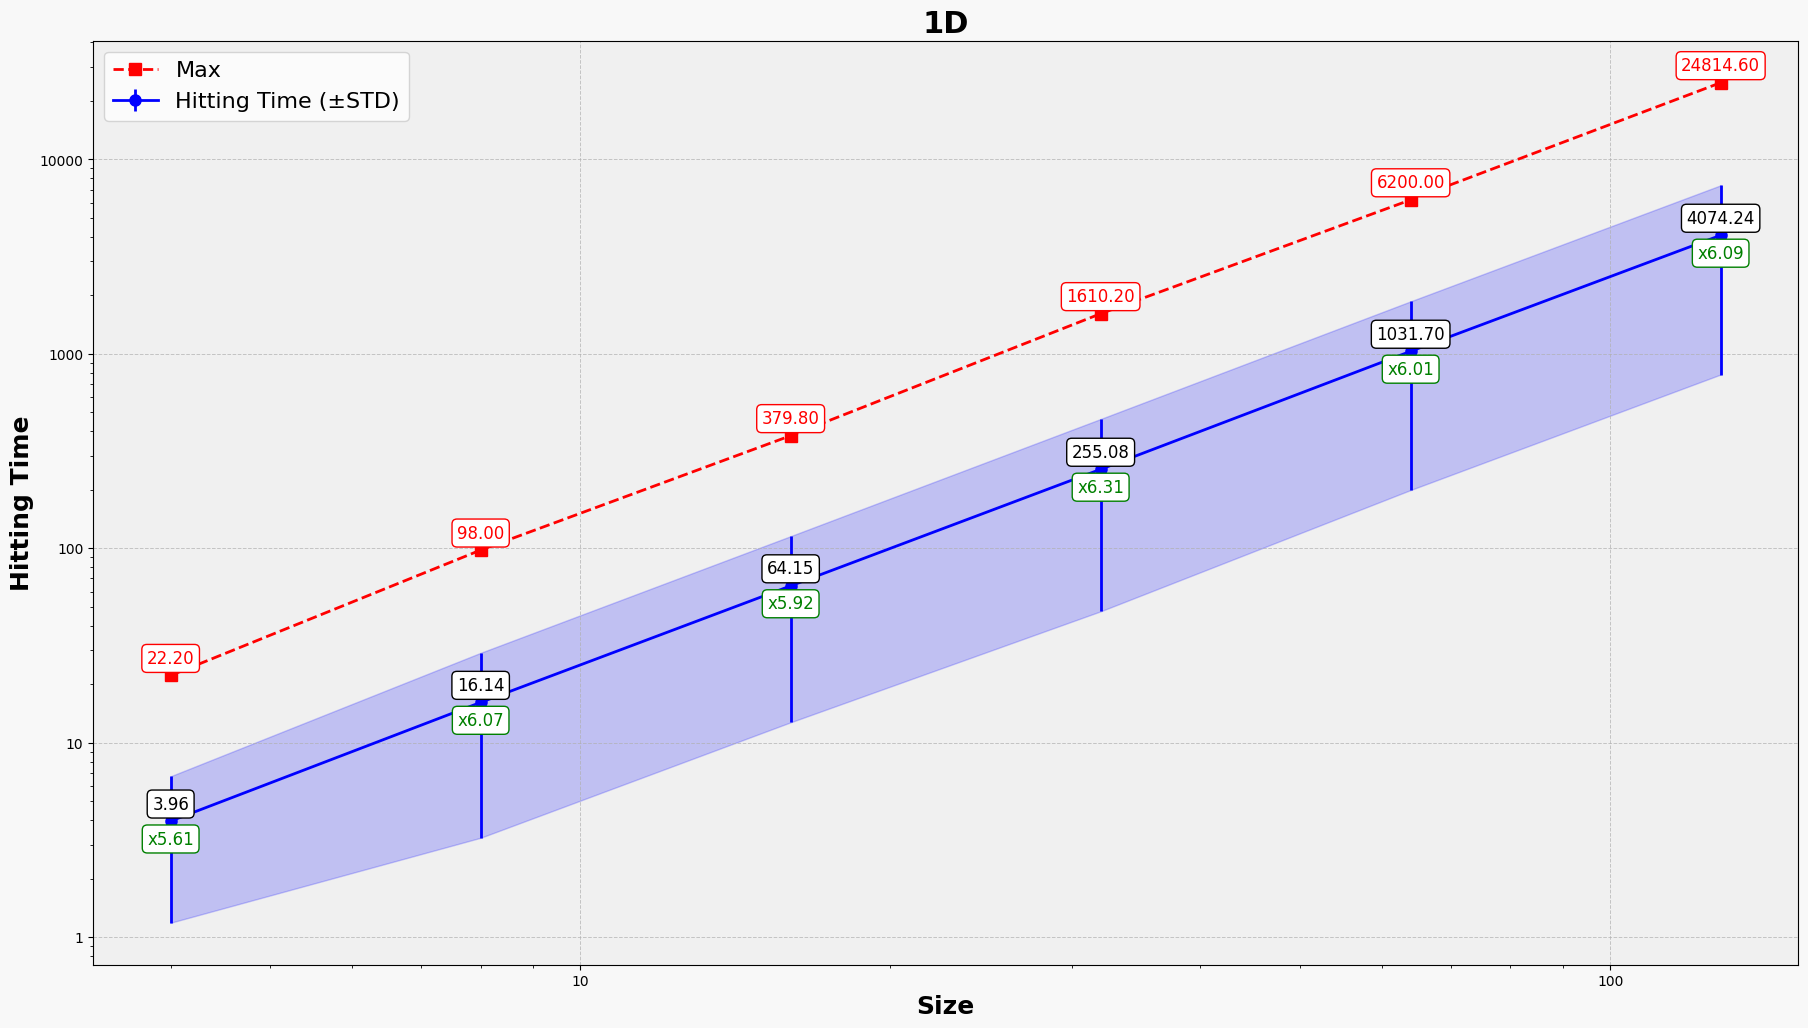

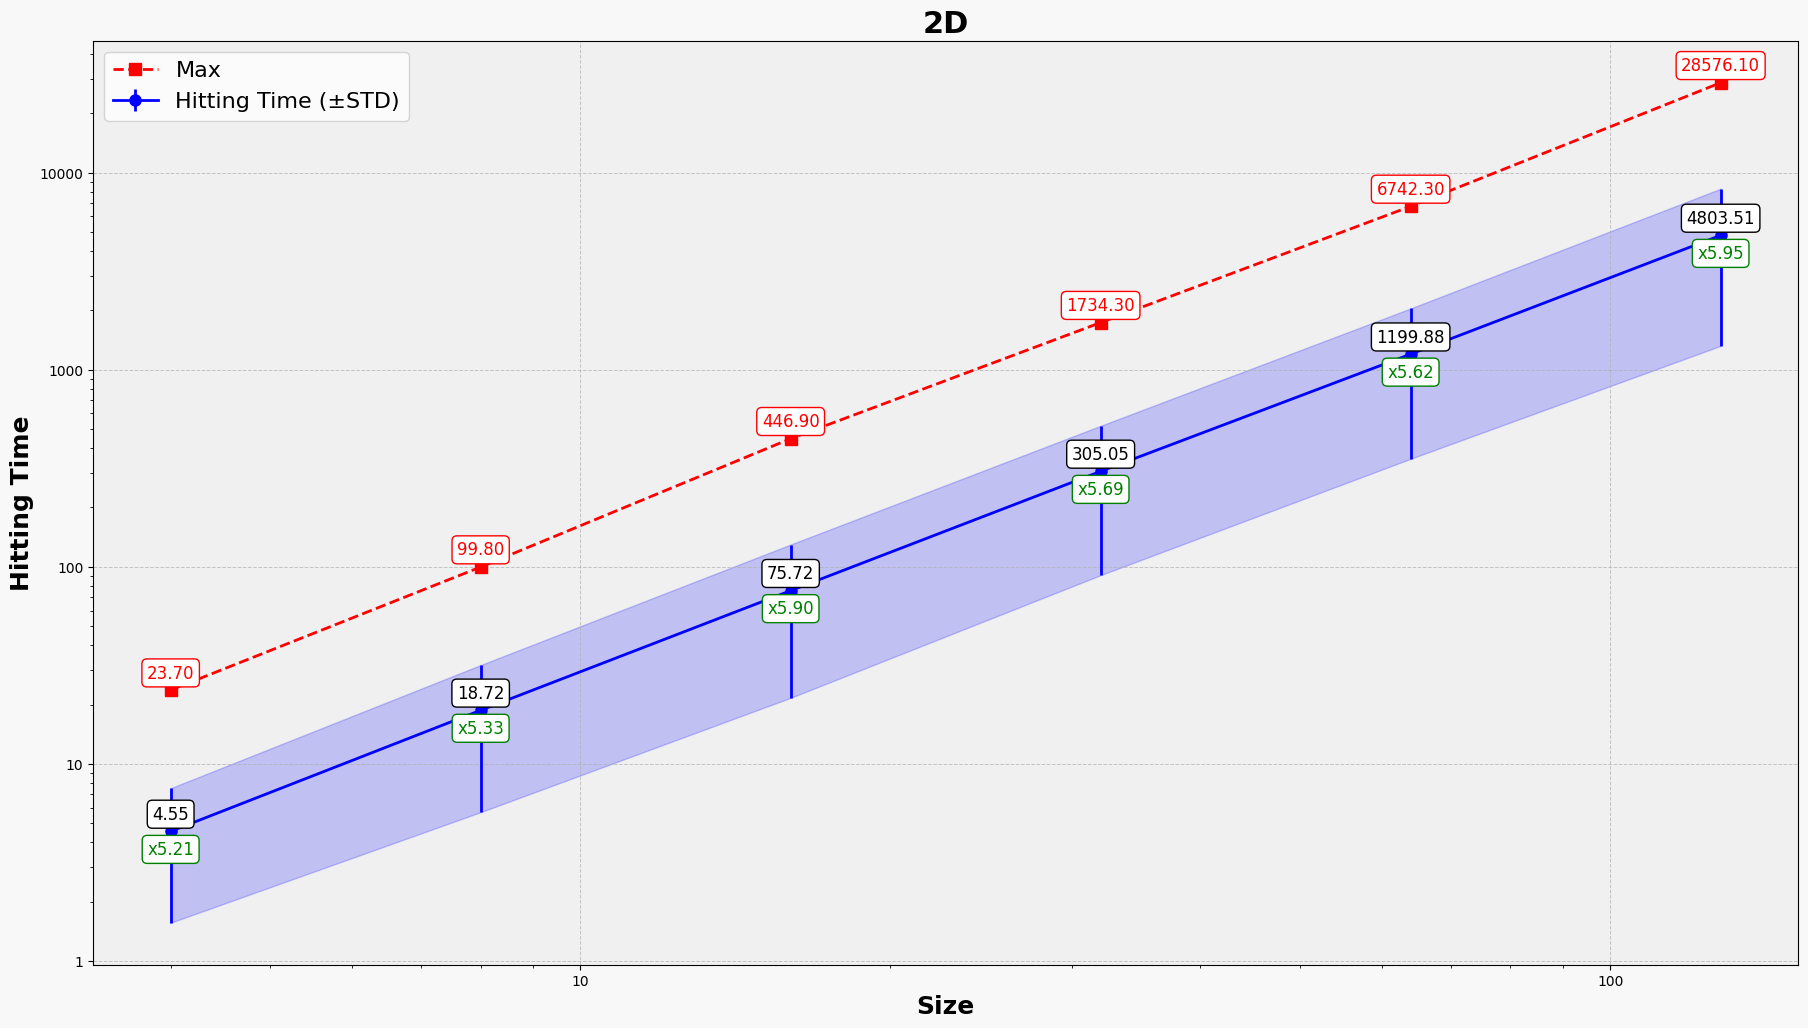

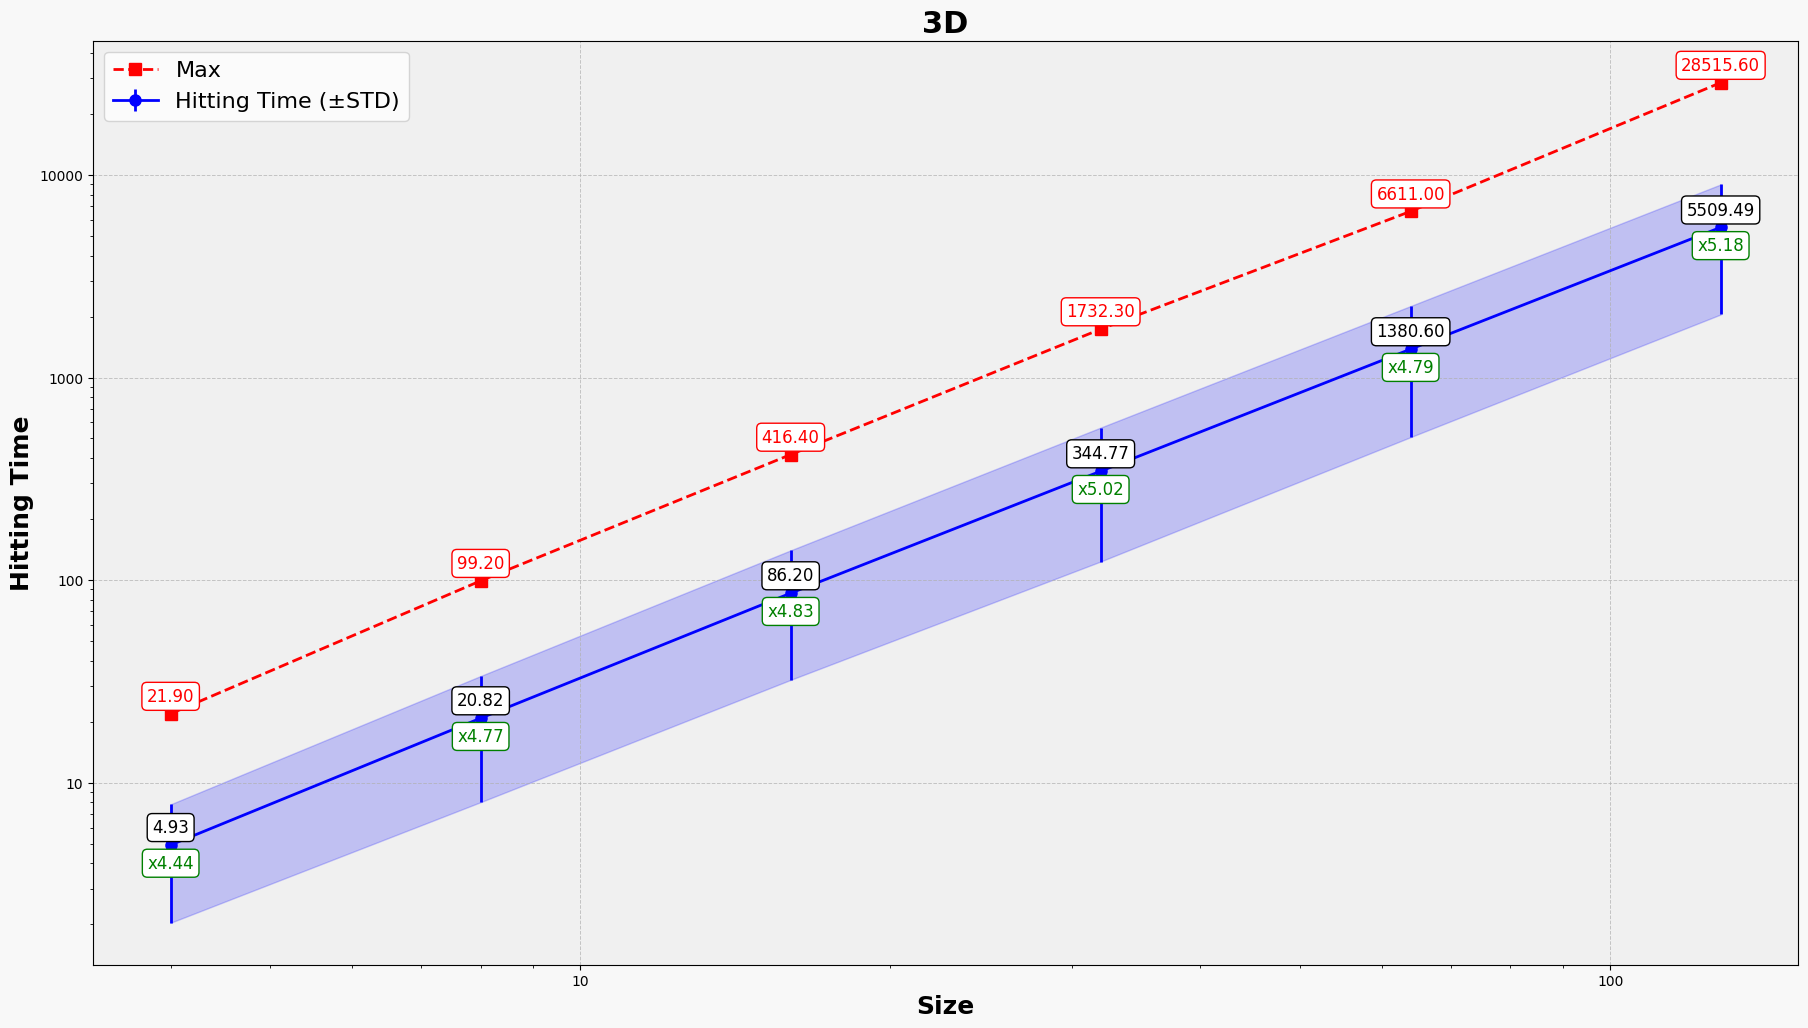

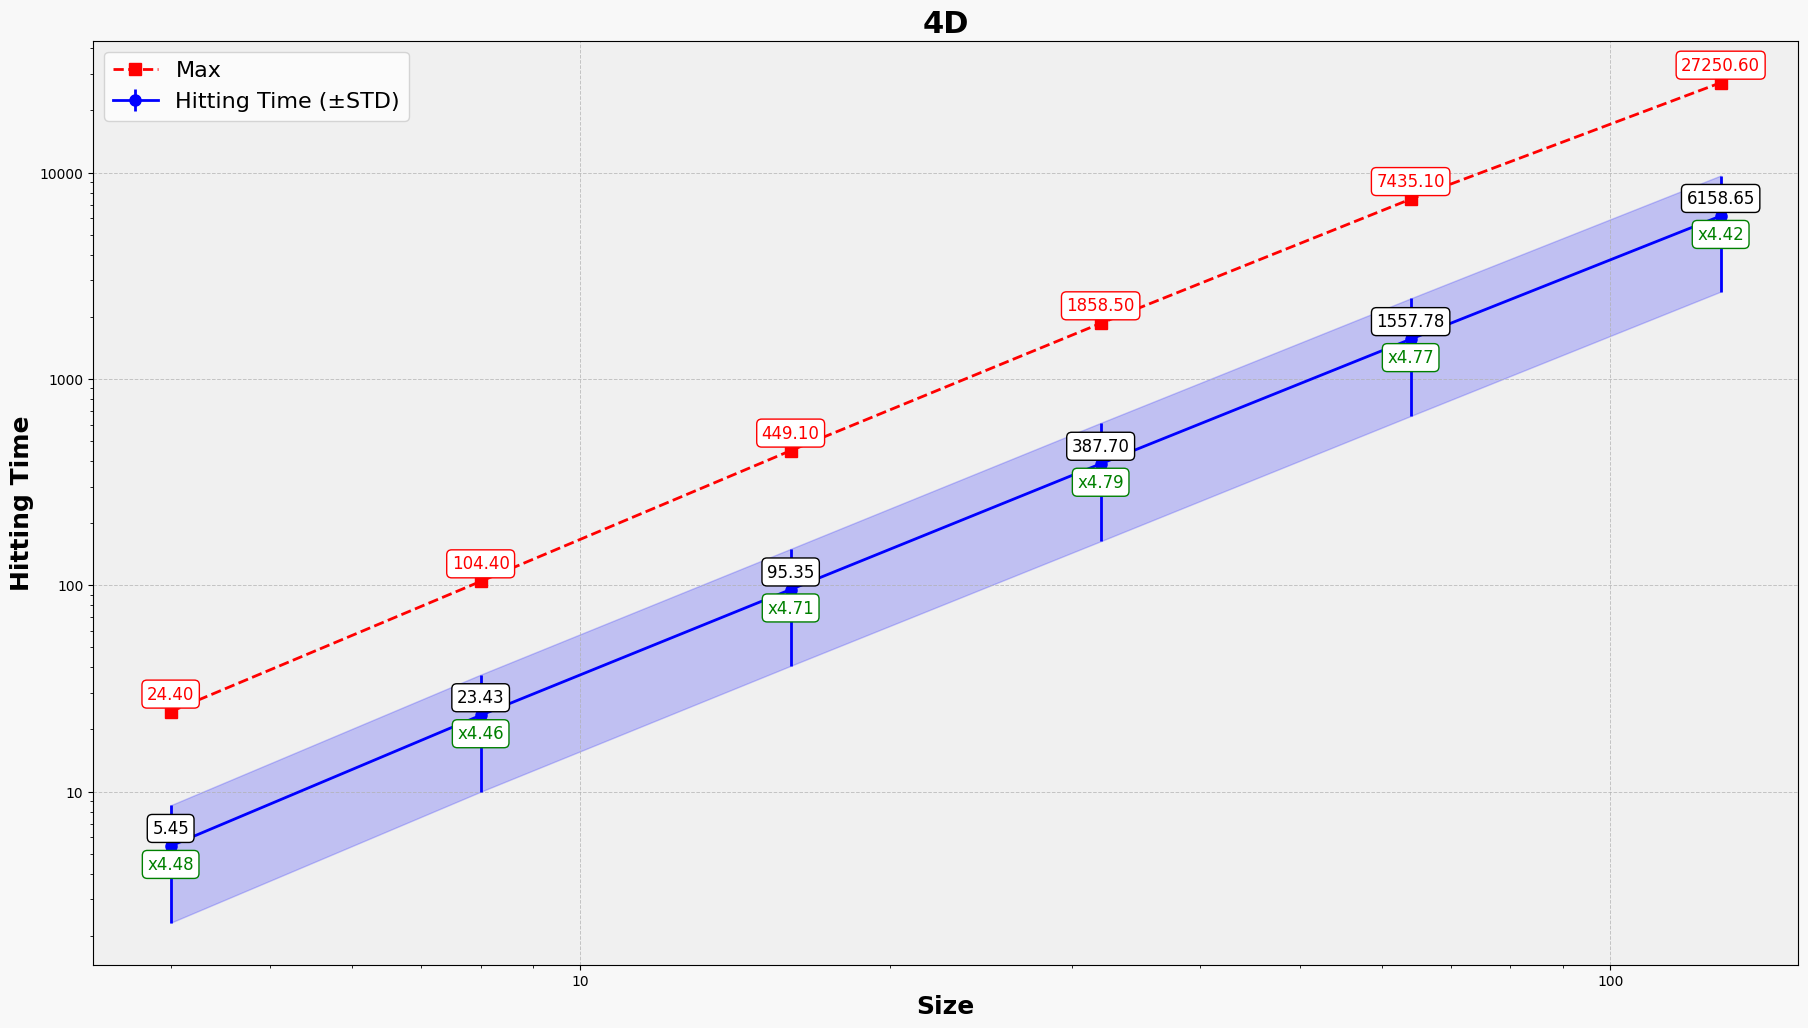

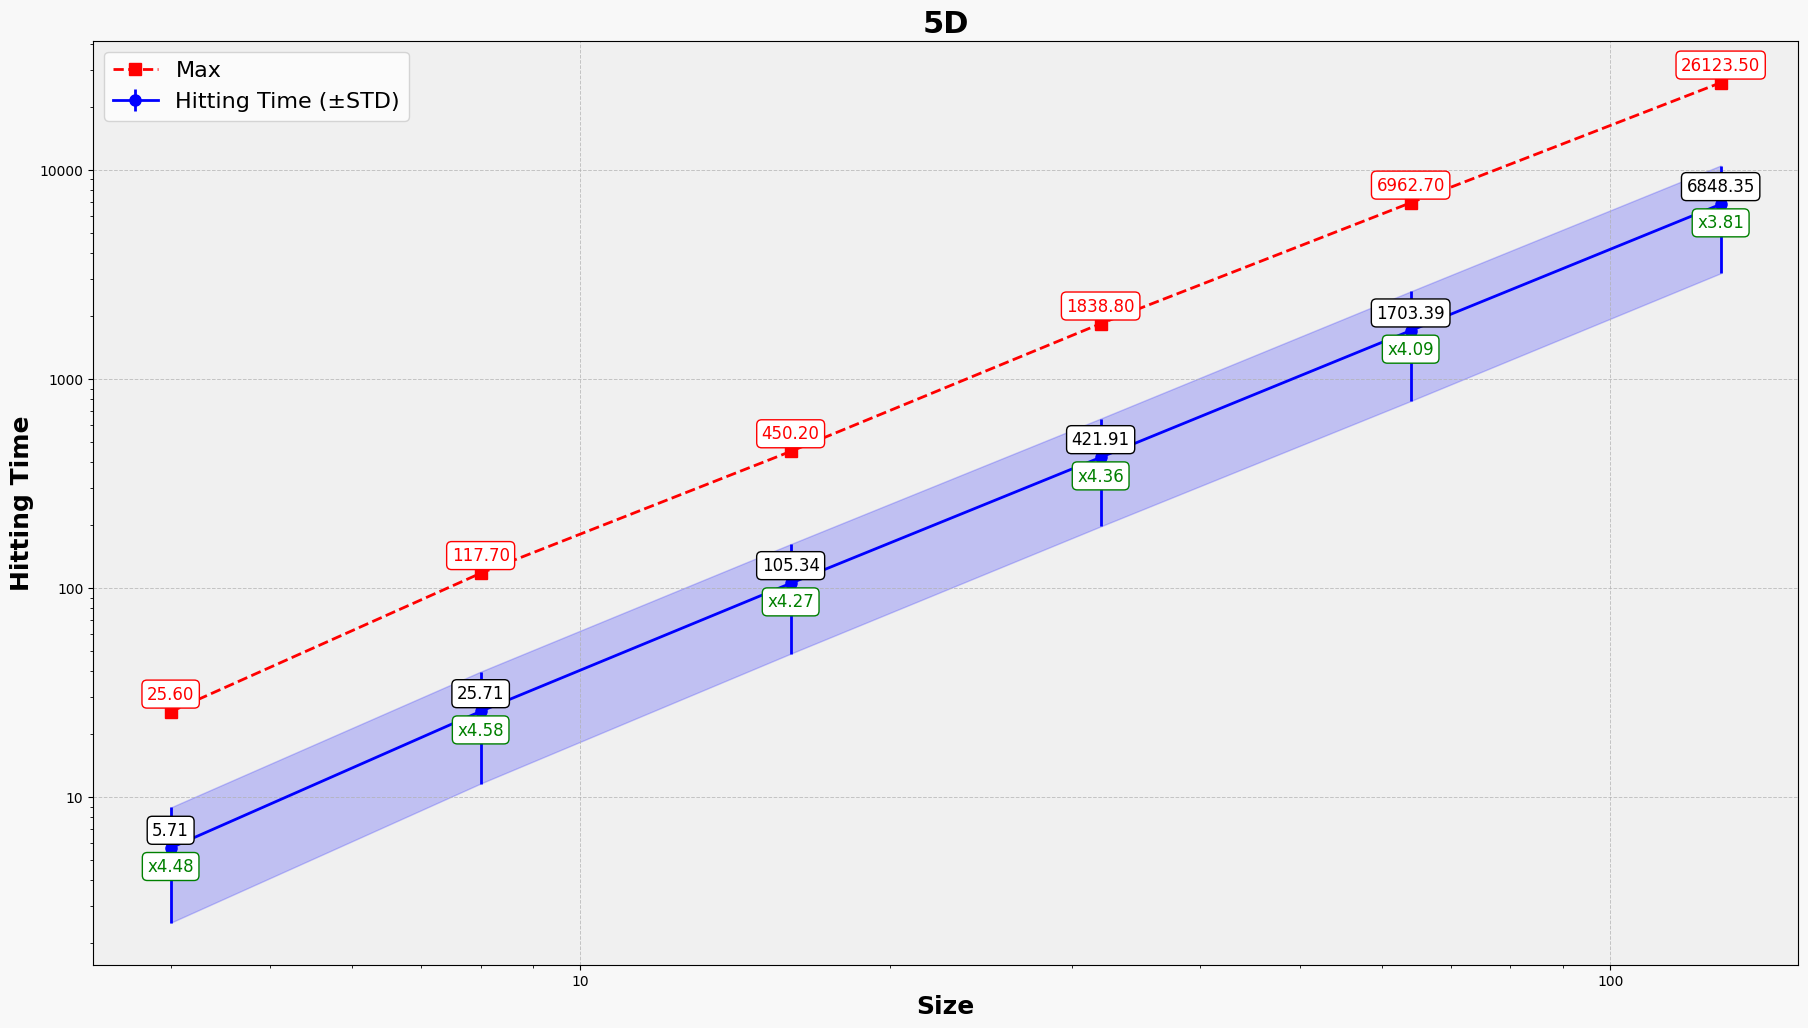

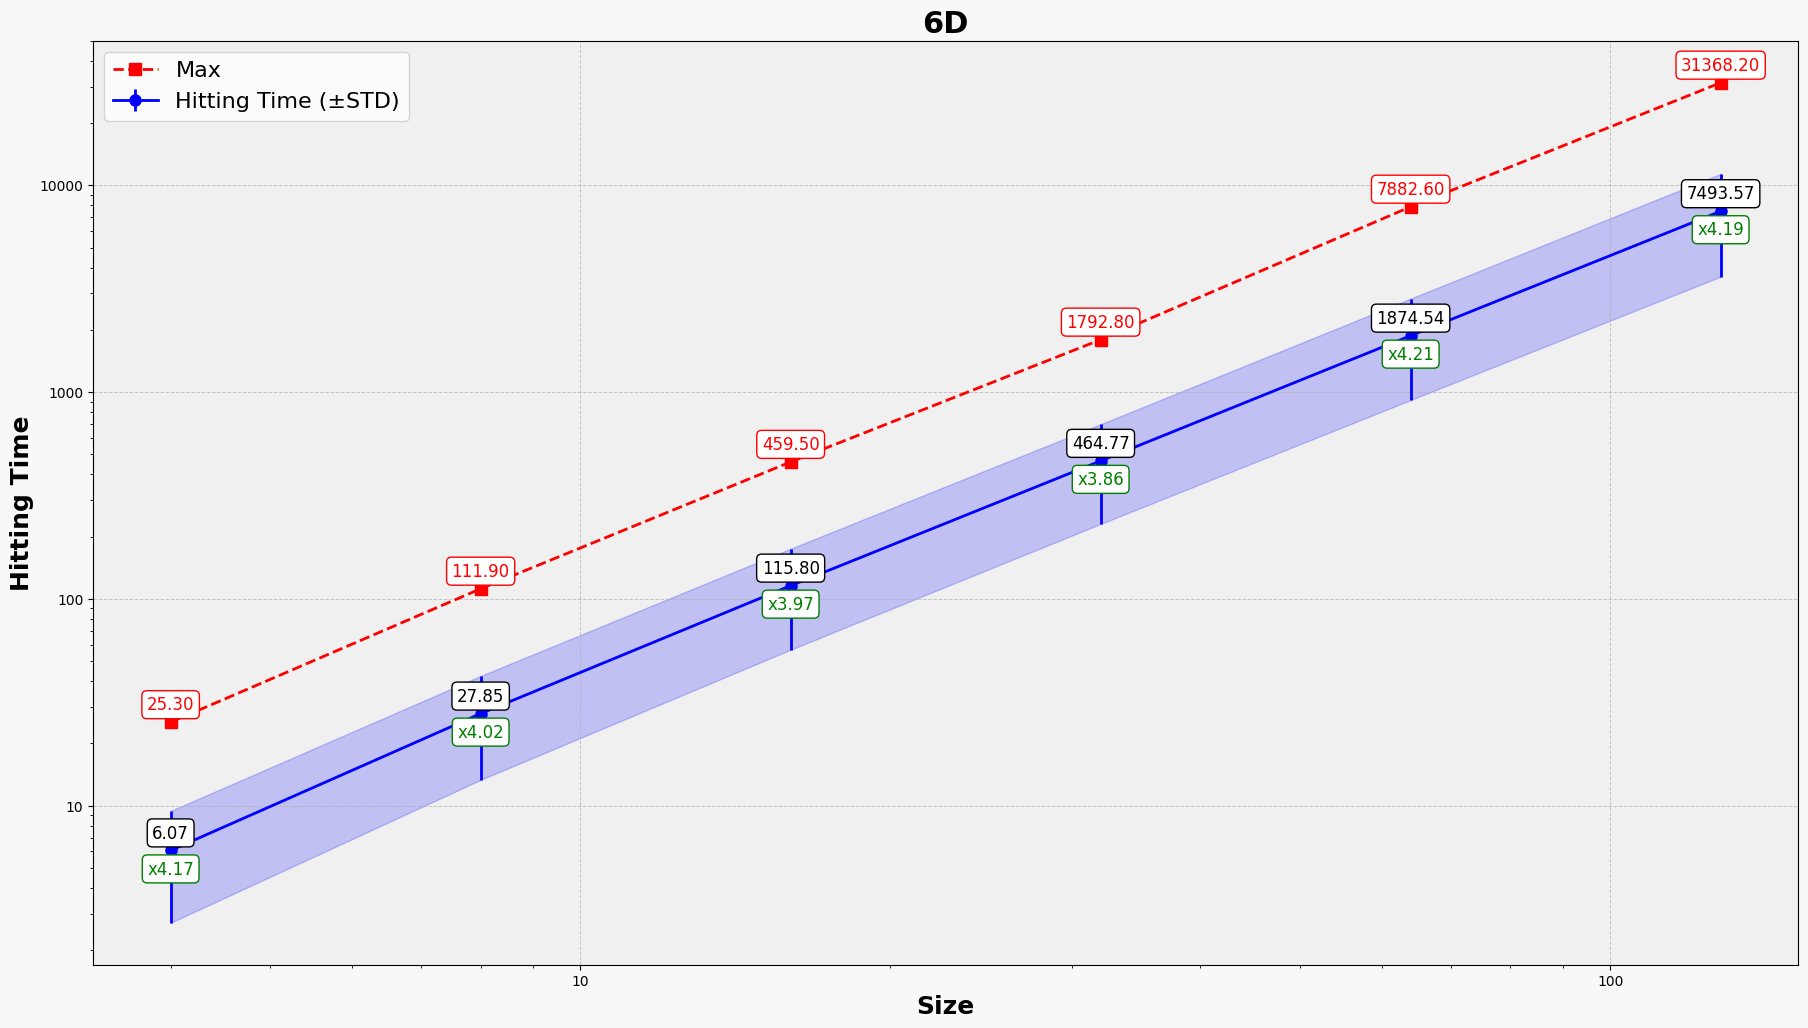

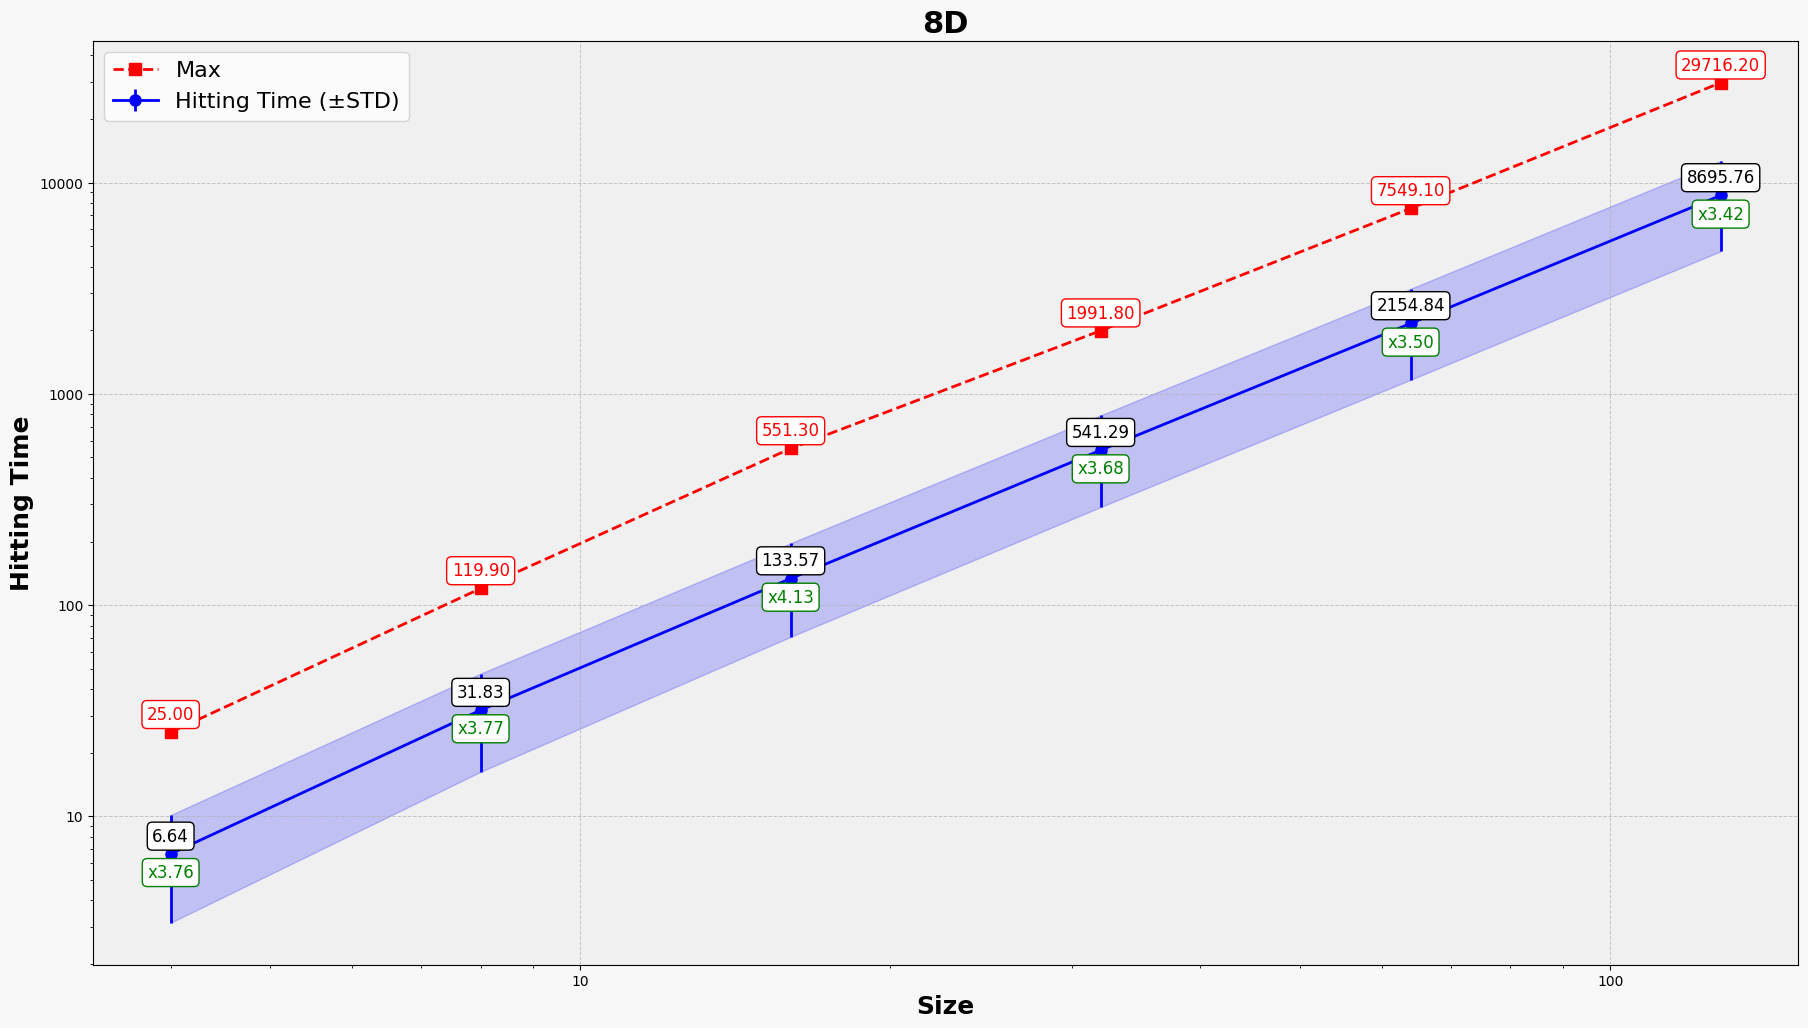

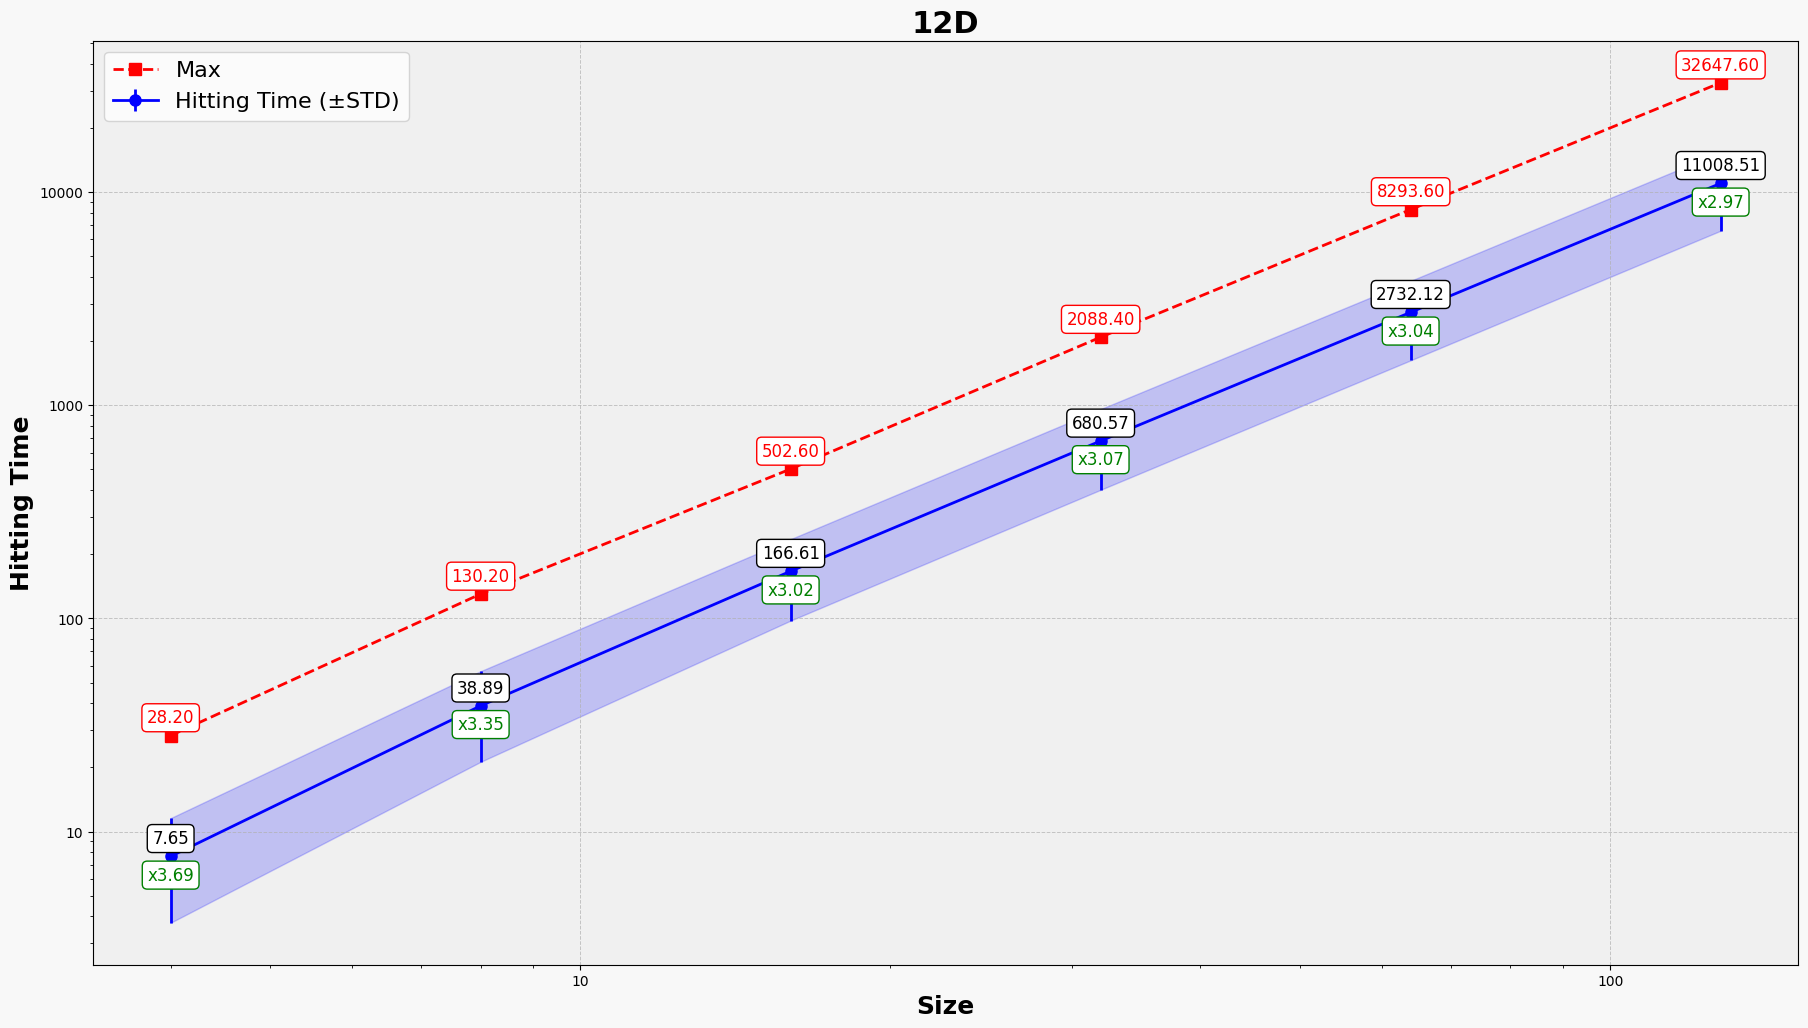

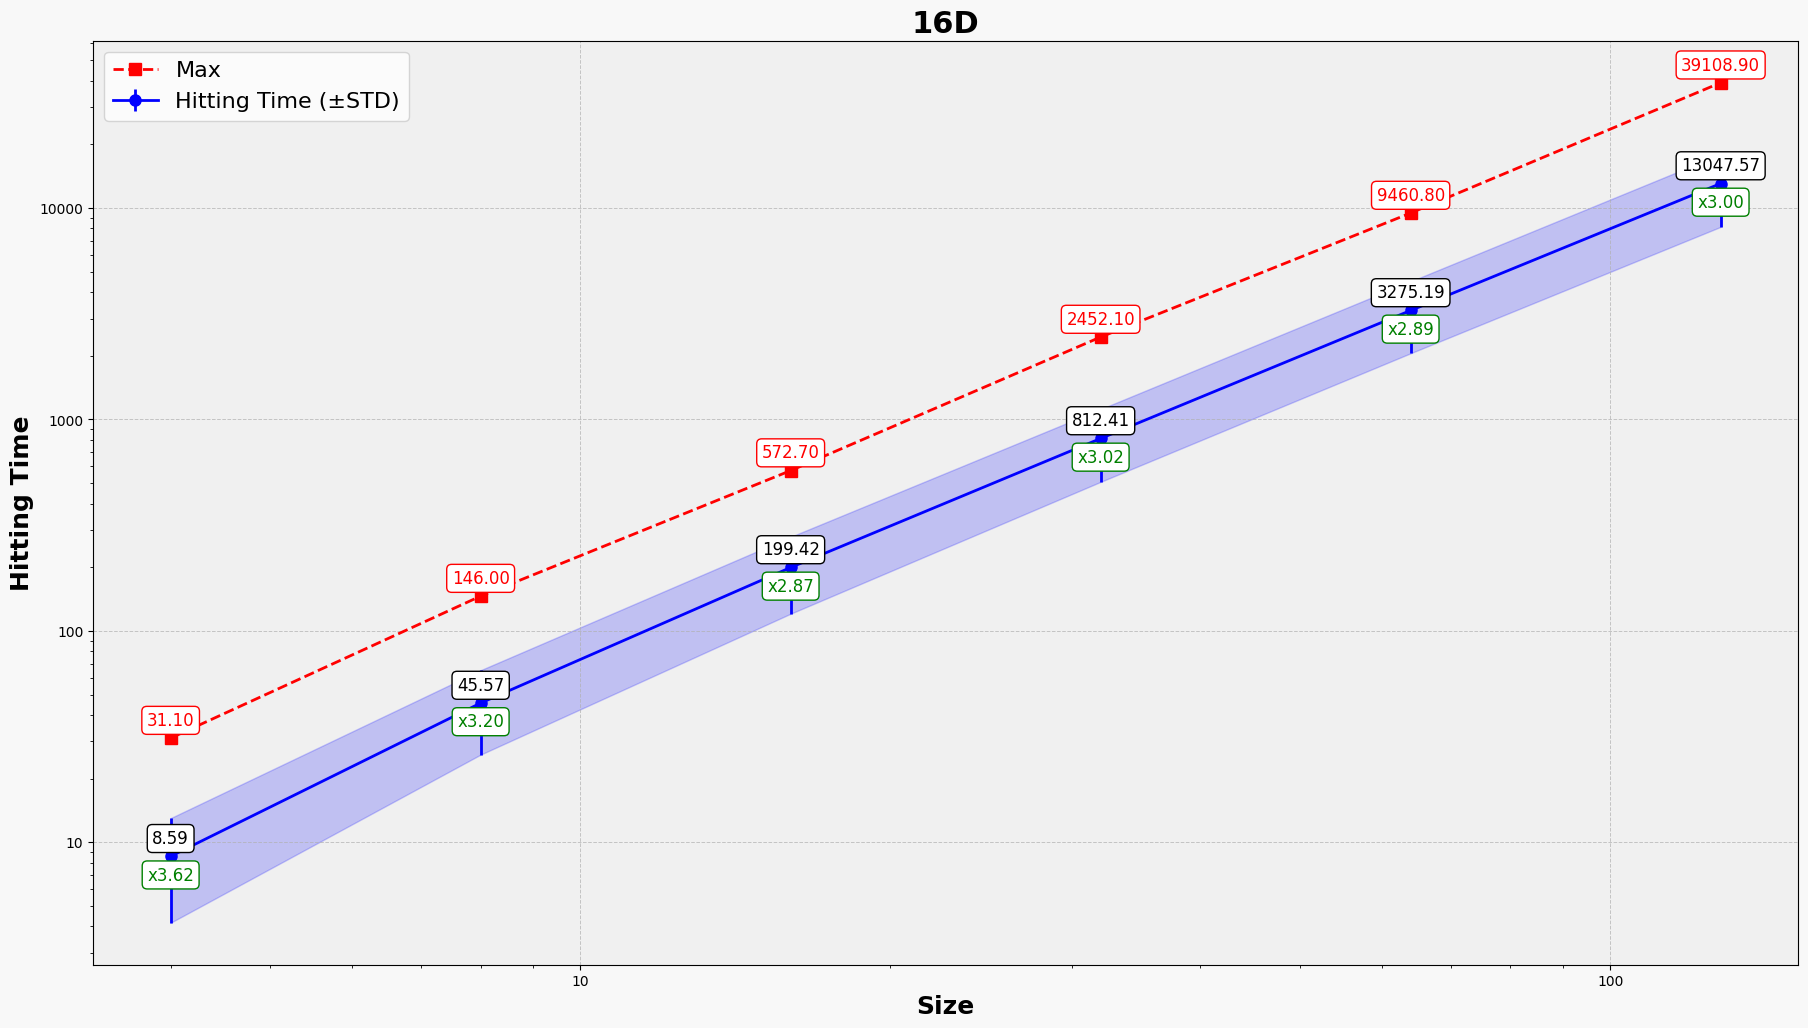

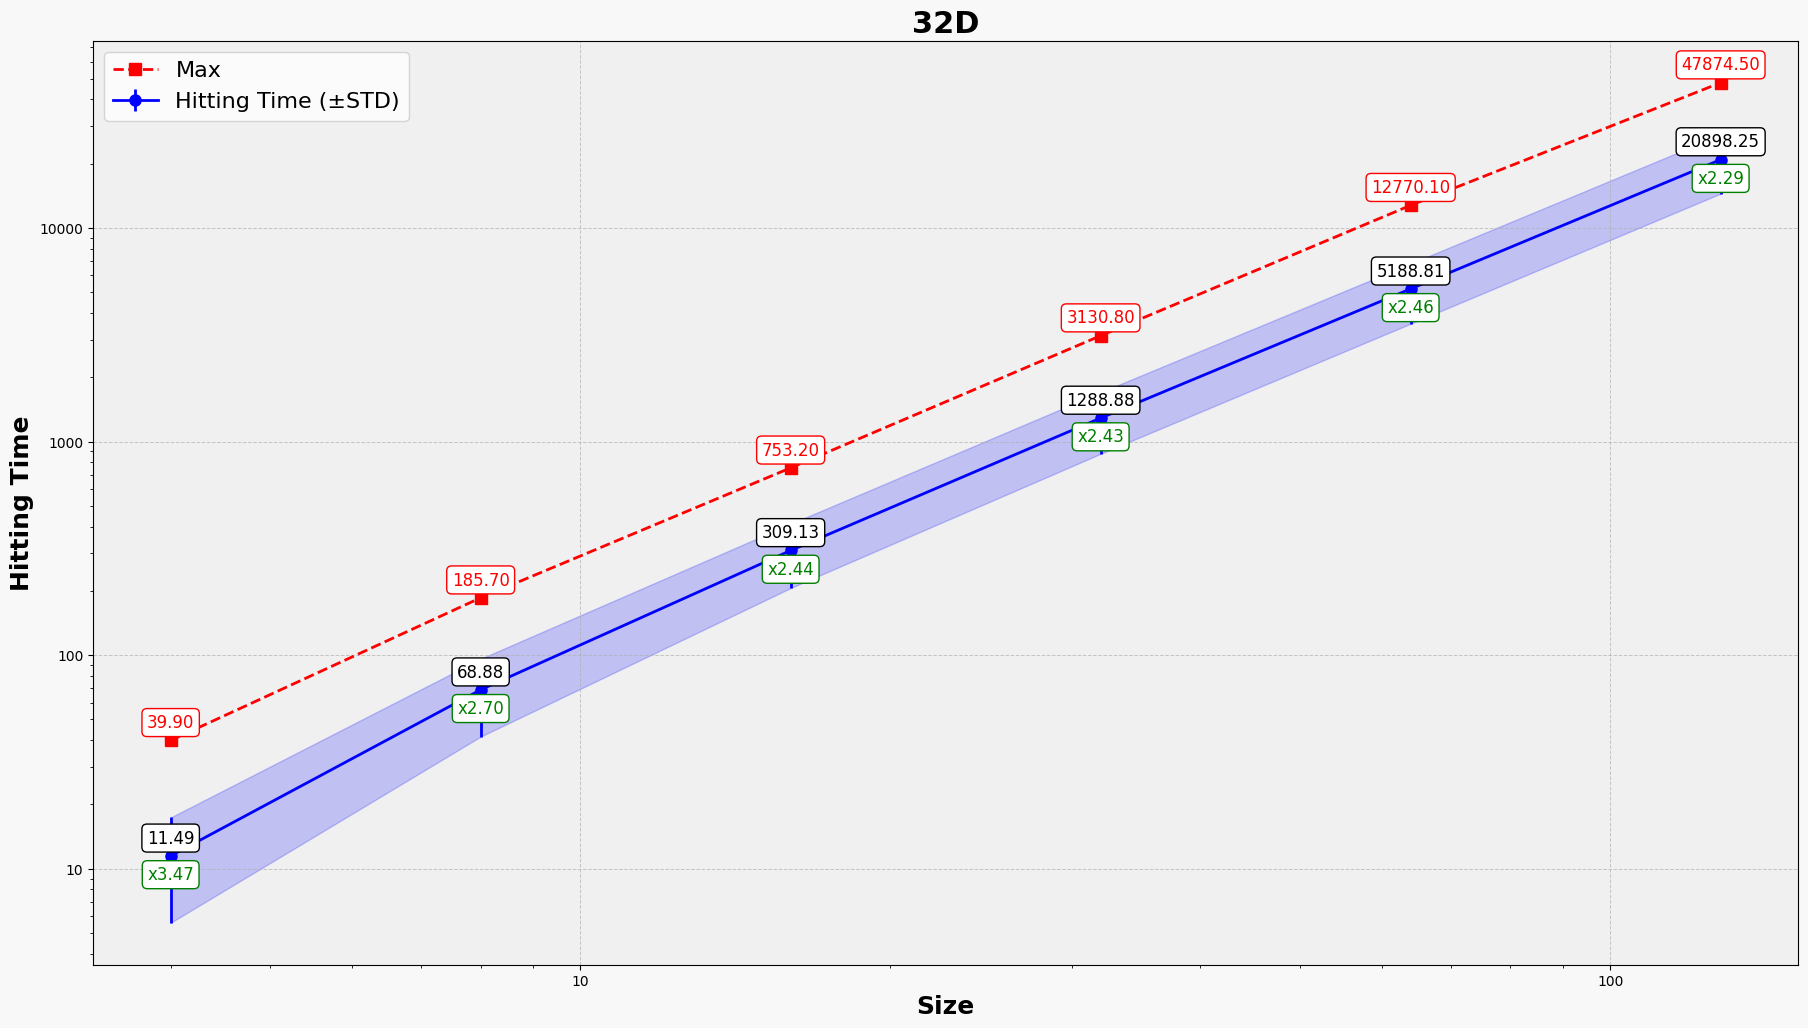

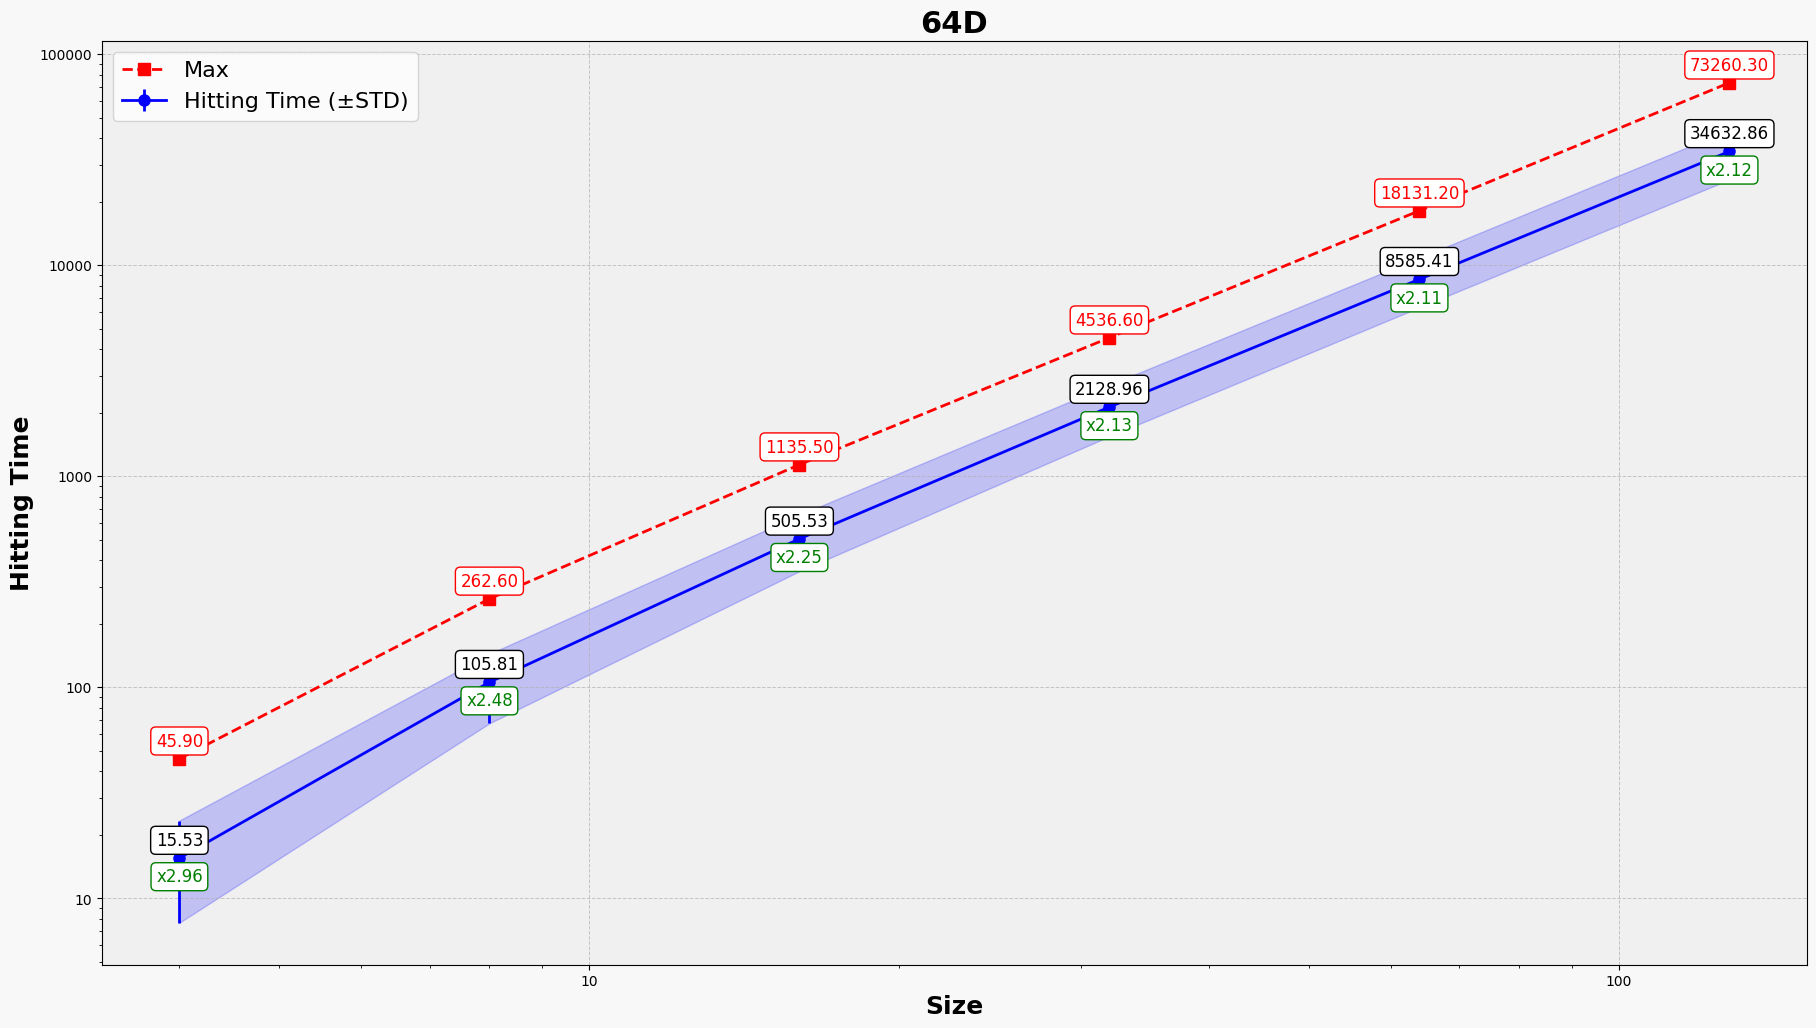

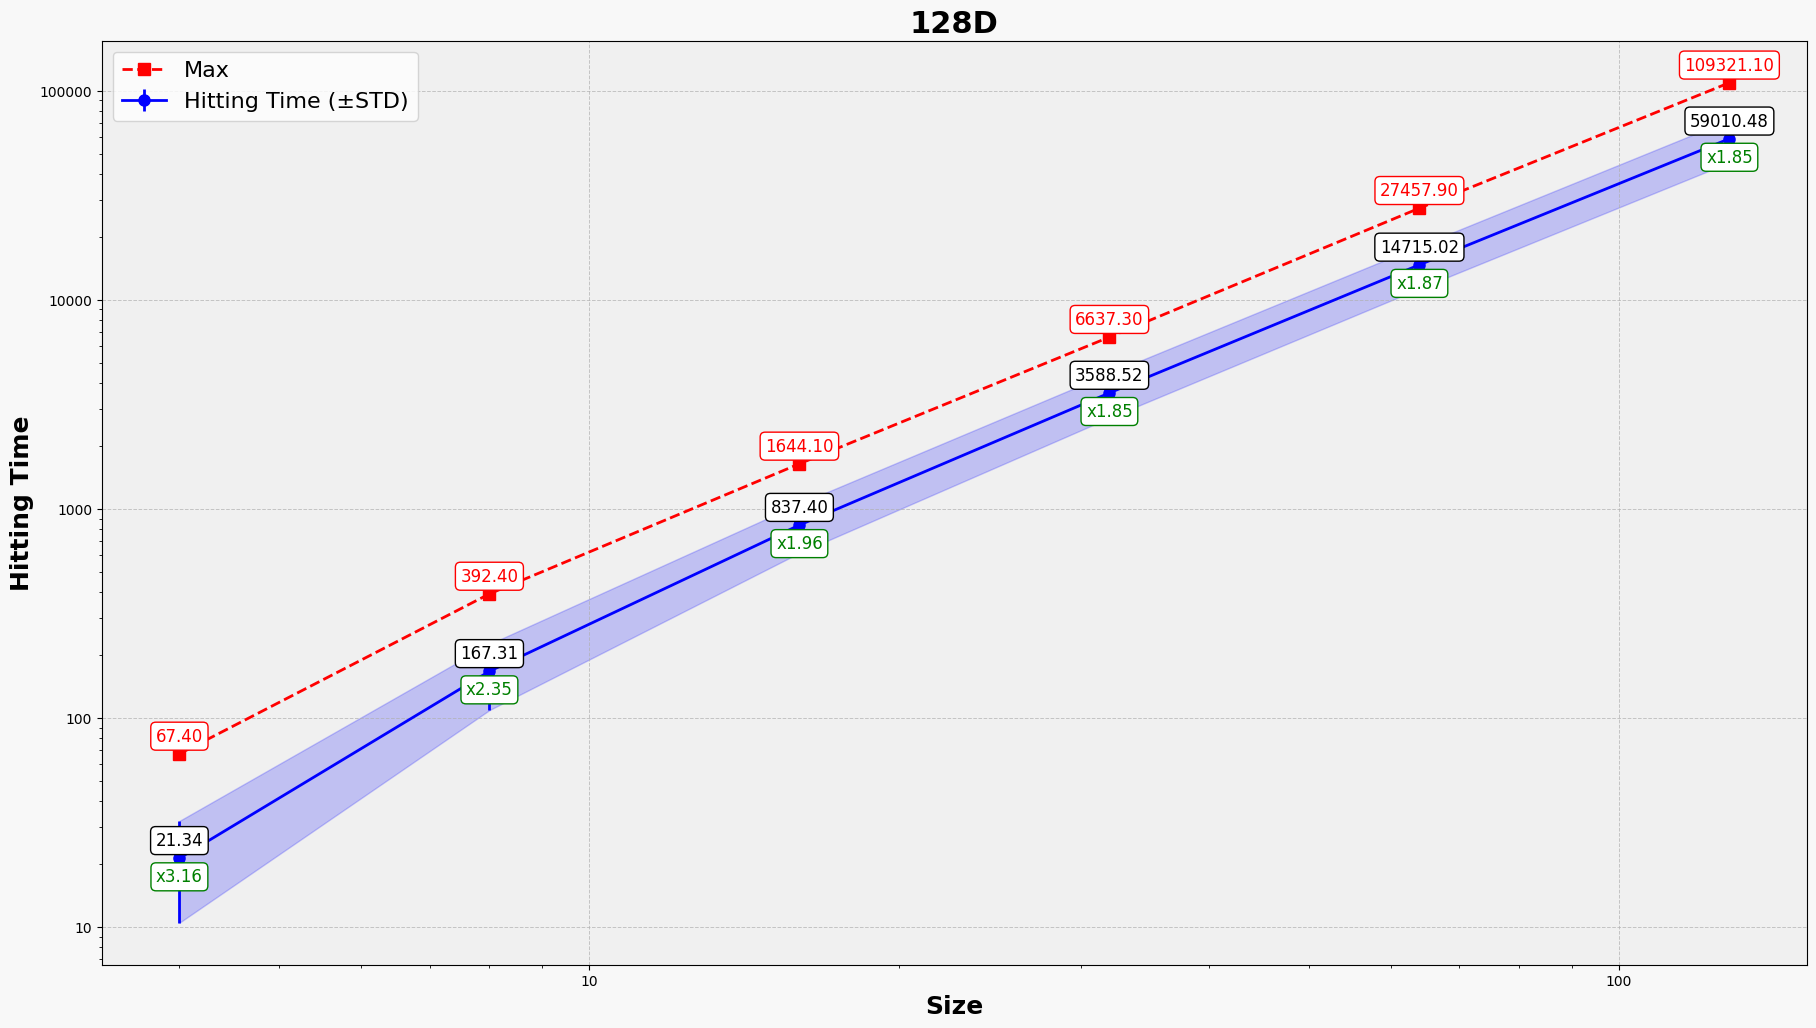

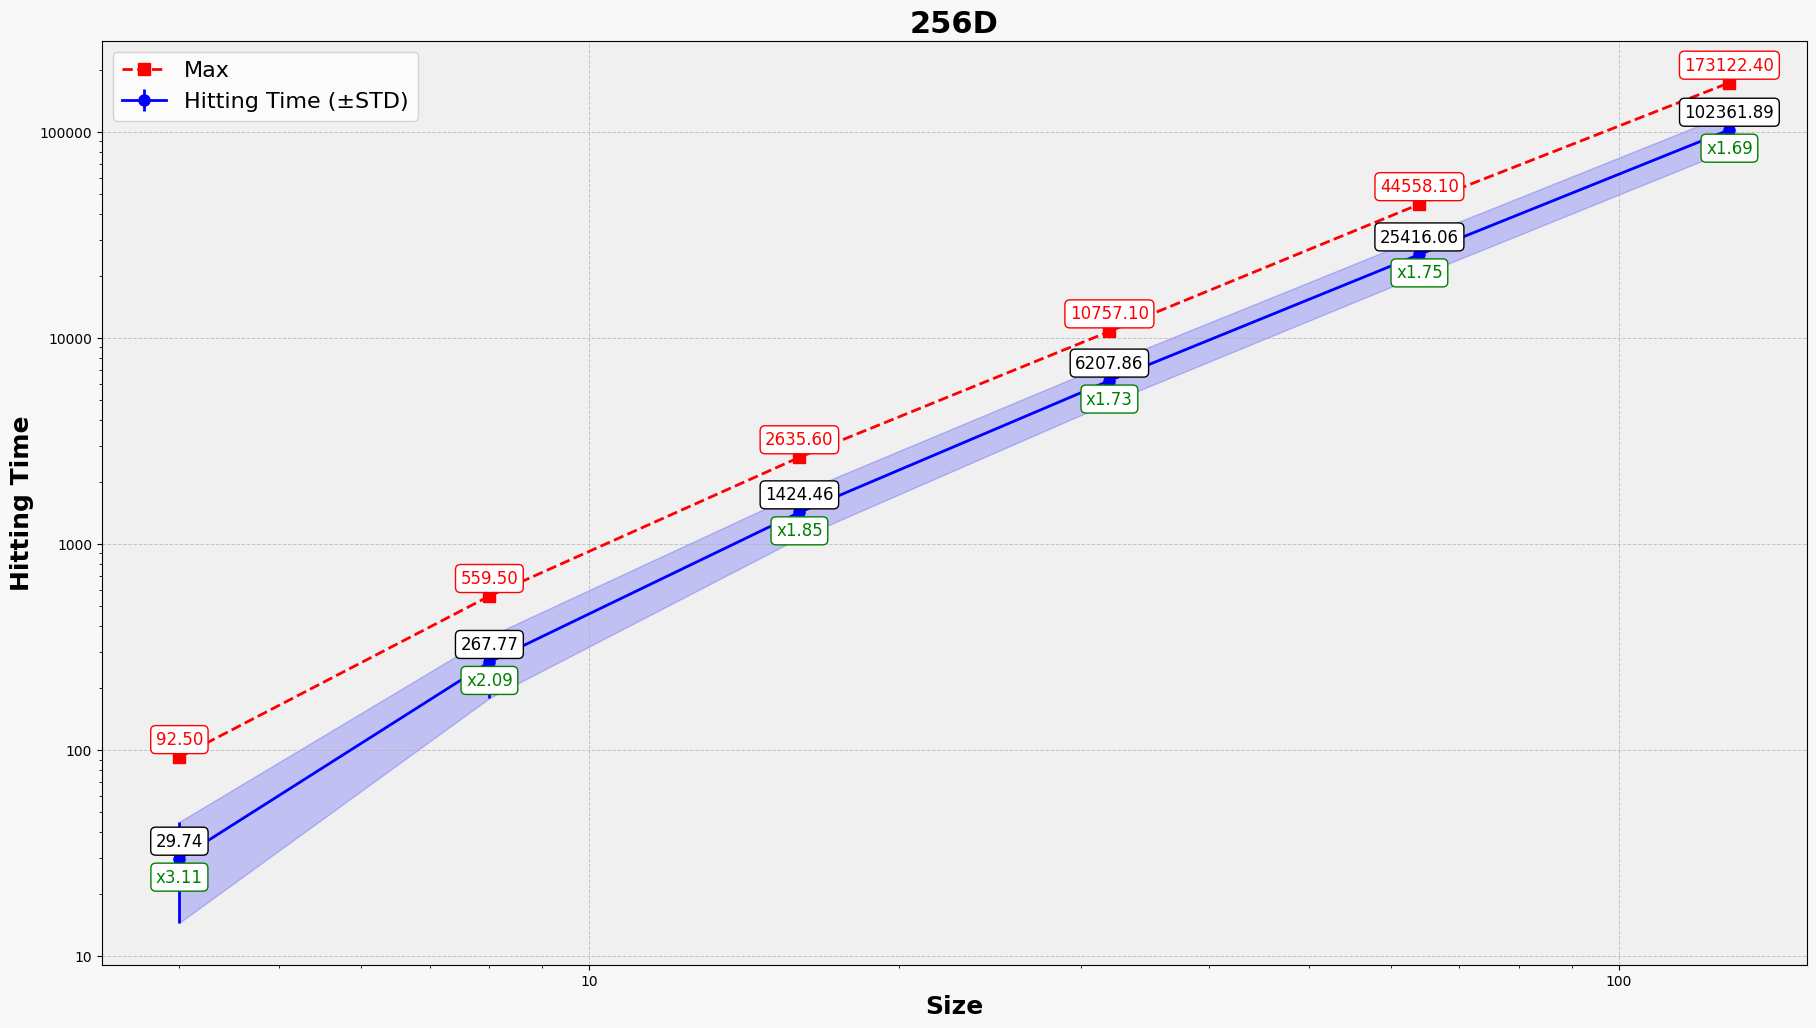

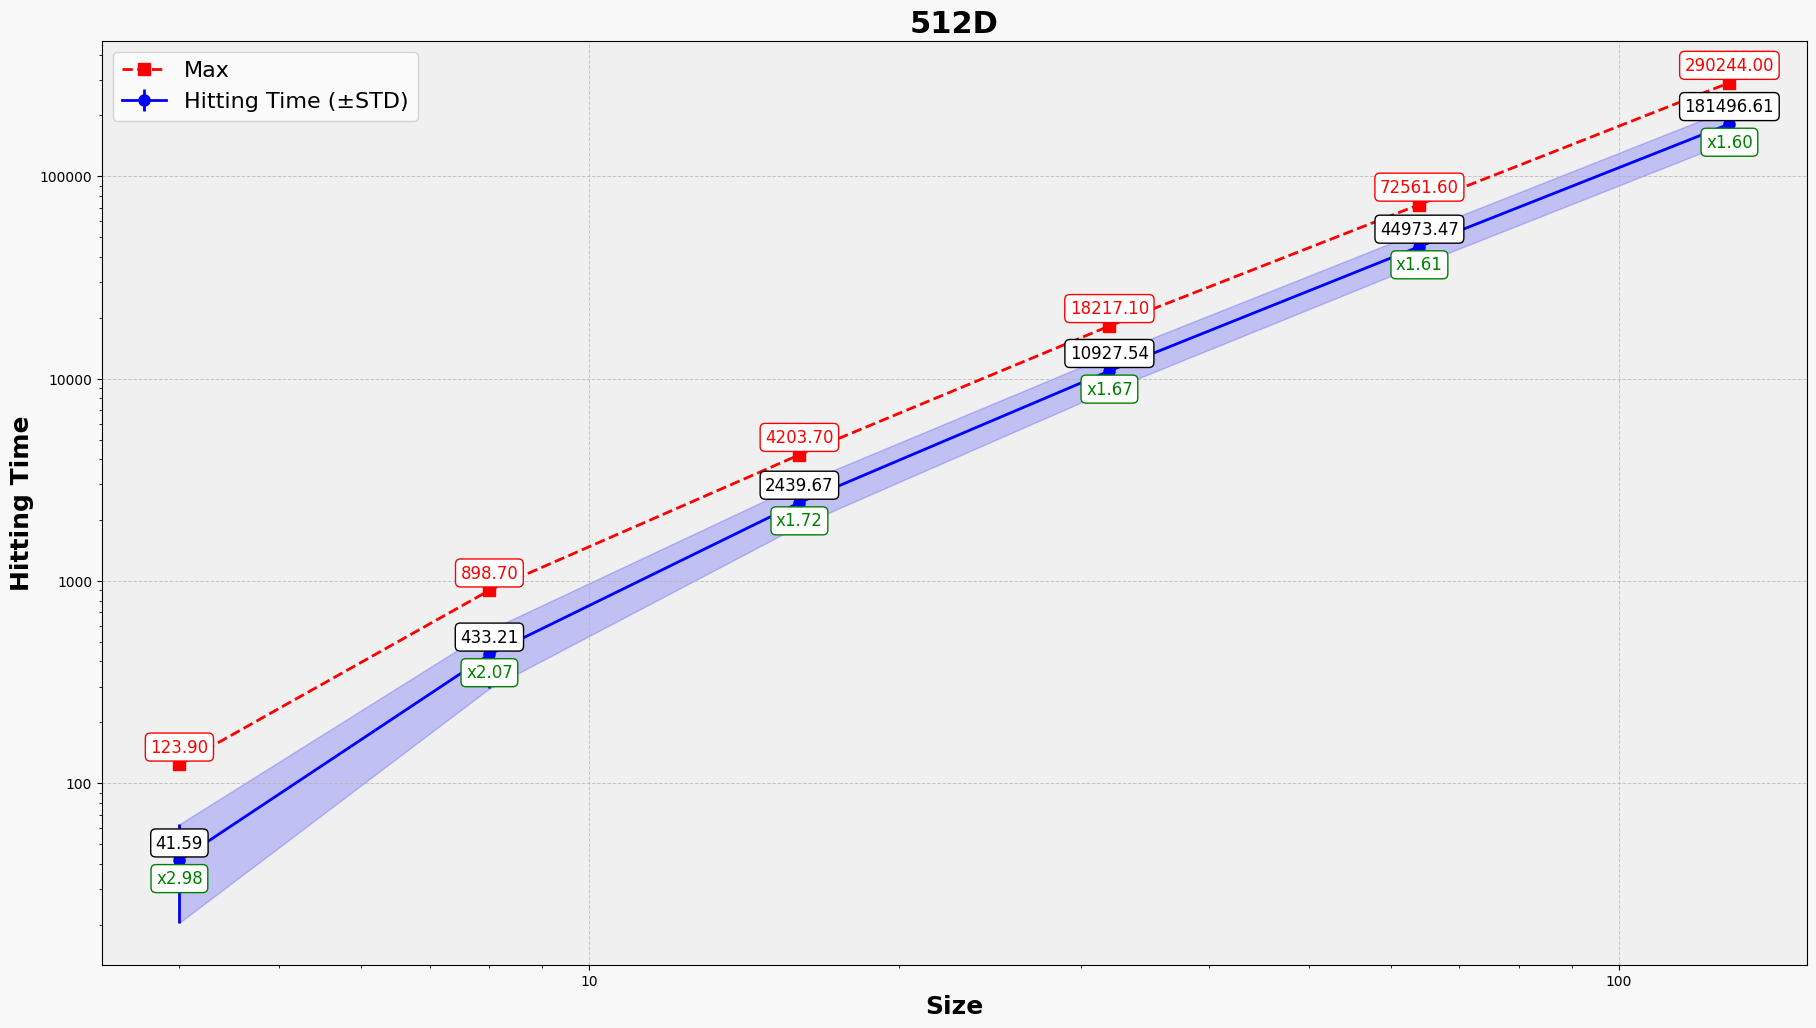

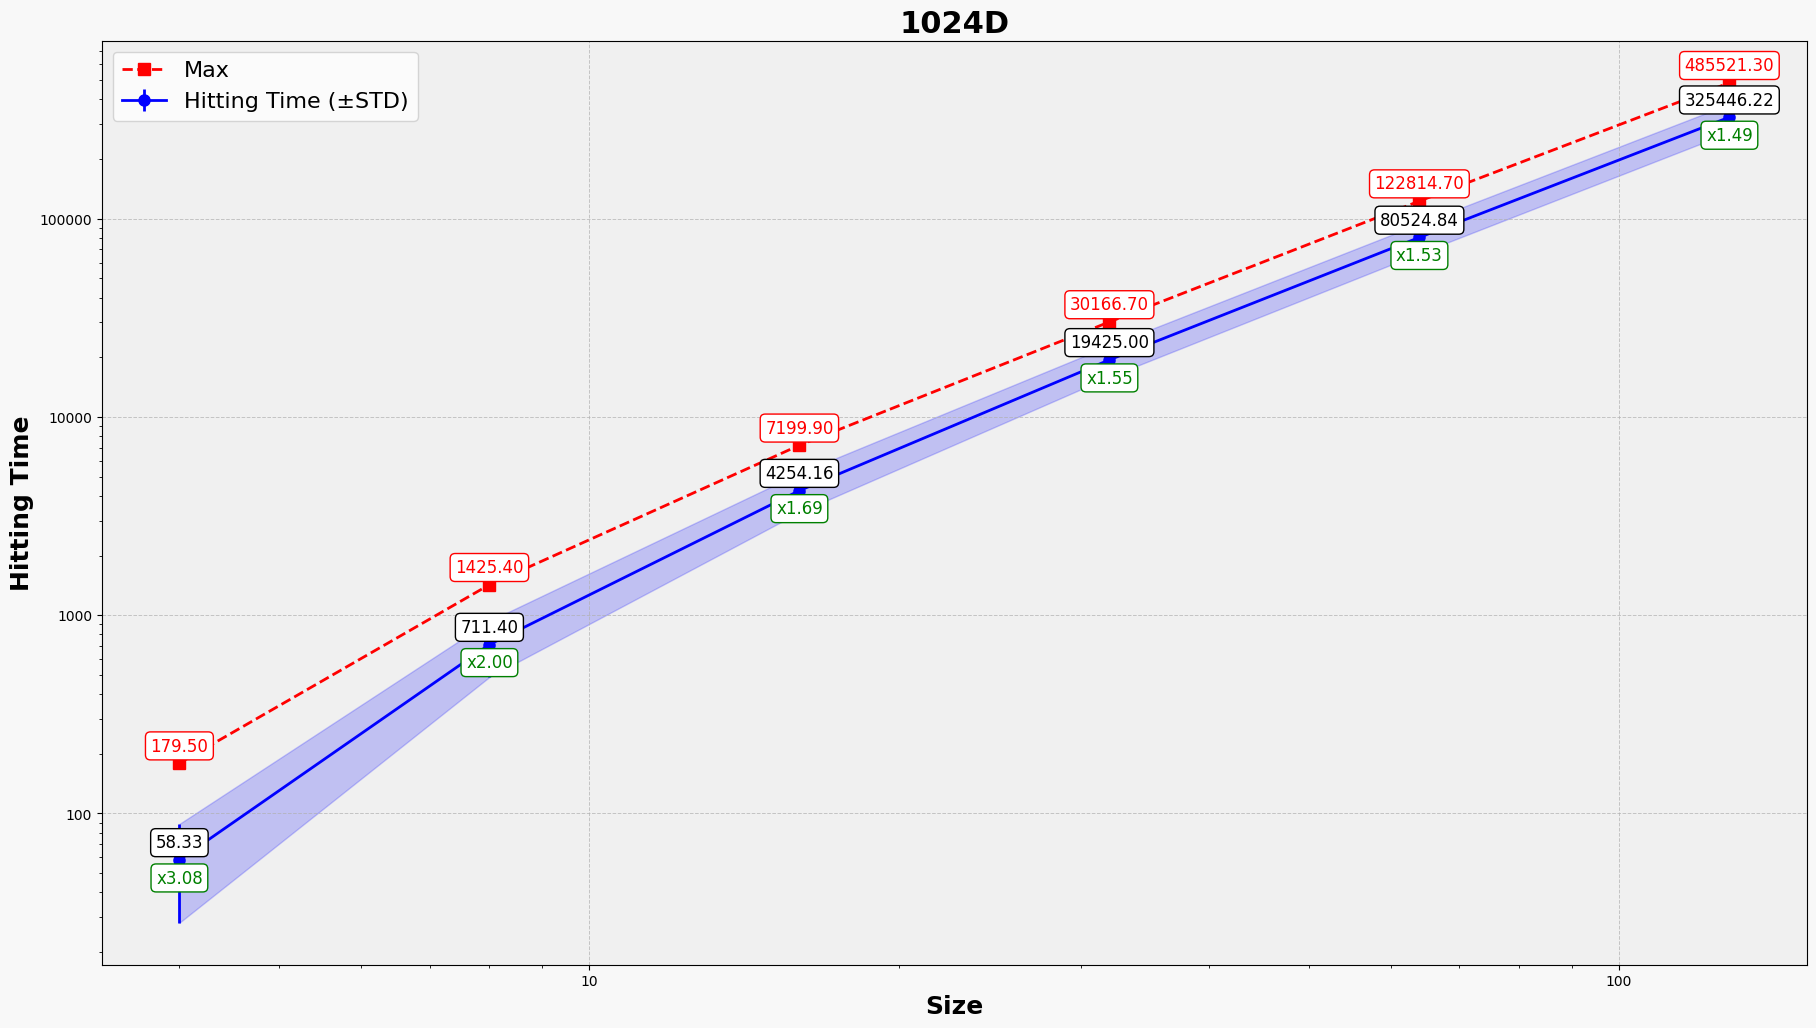

In [8]:
for dimension in [1, 2, 3, 4, 5, 6, 8, 12, 16, 32, 64, 128, 256, 512, 1024]:
    plot_hitting_time(get_data(dimension, "../data/symmetry_walks.csv"))

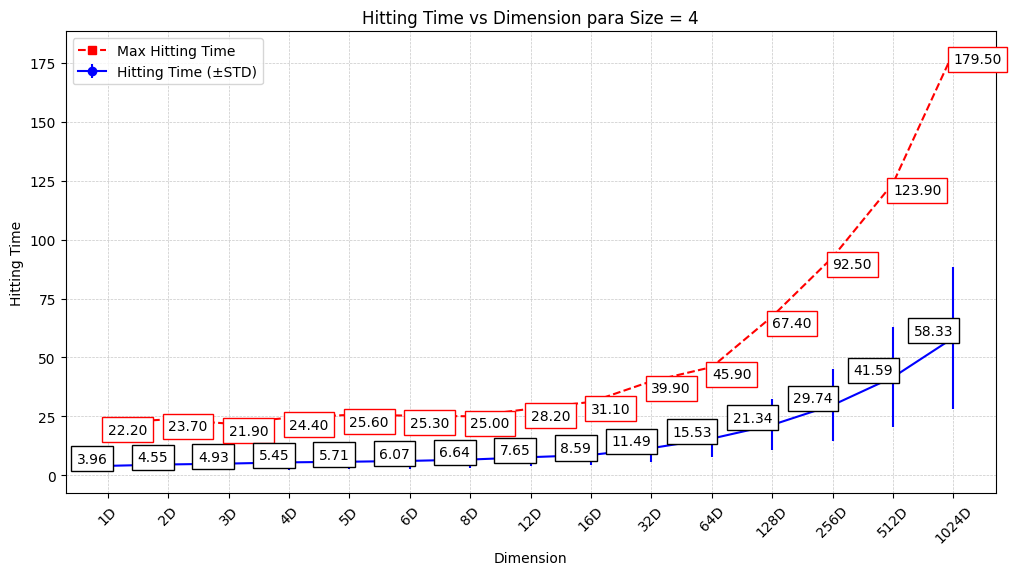

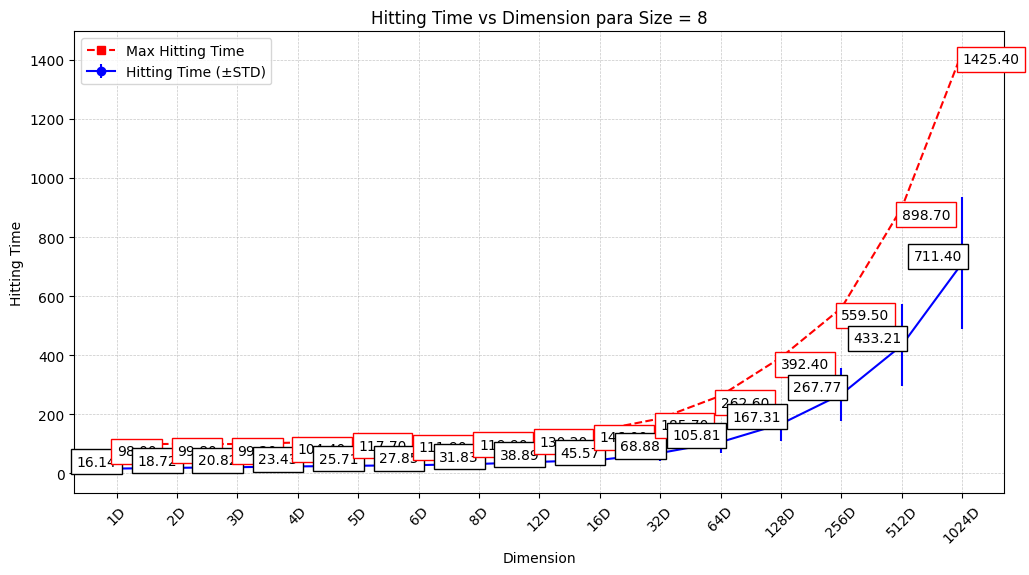

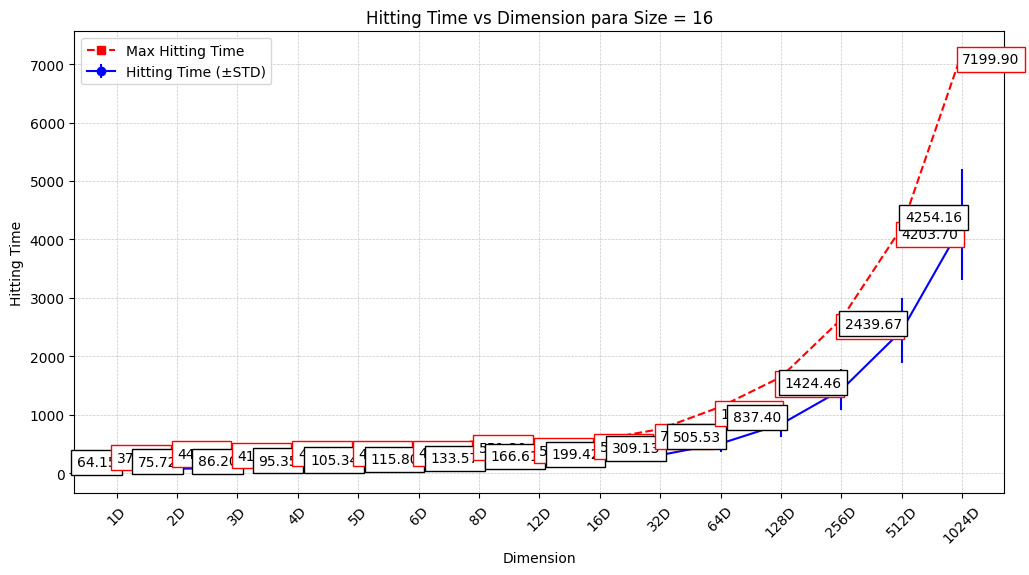

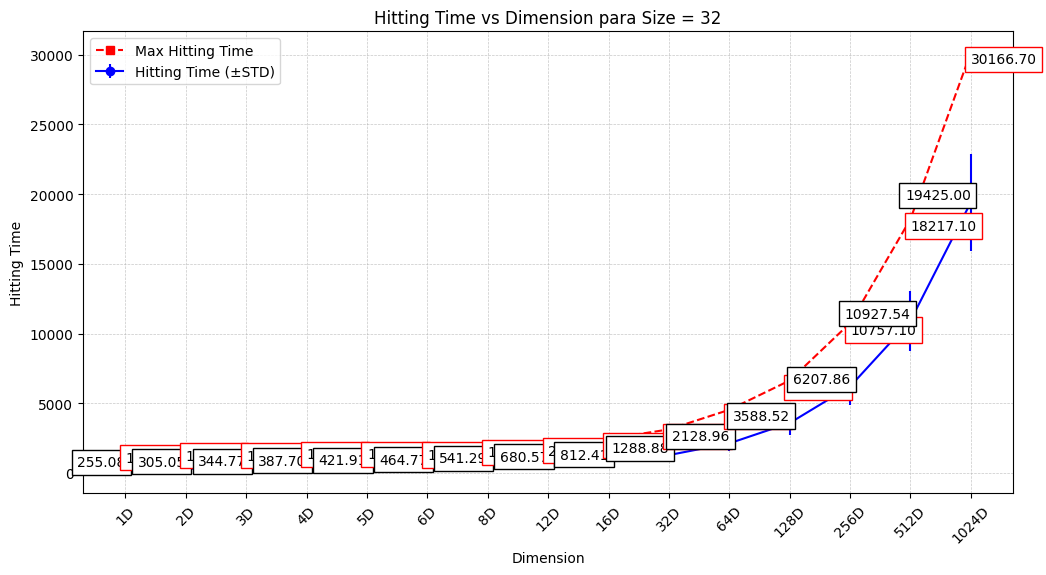

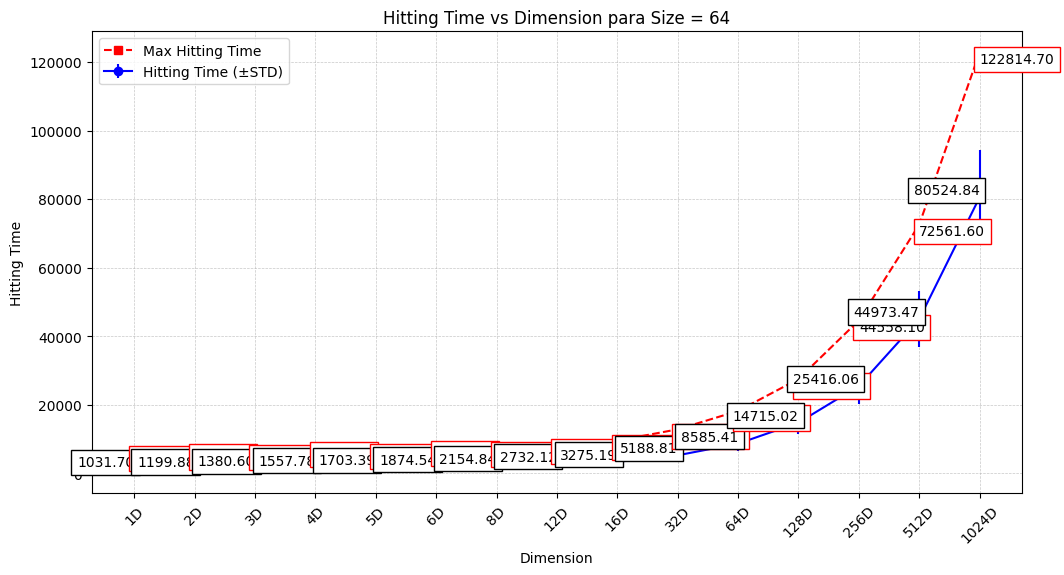

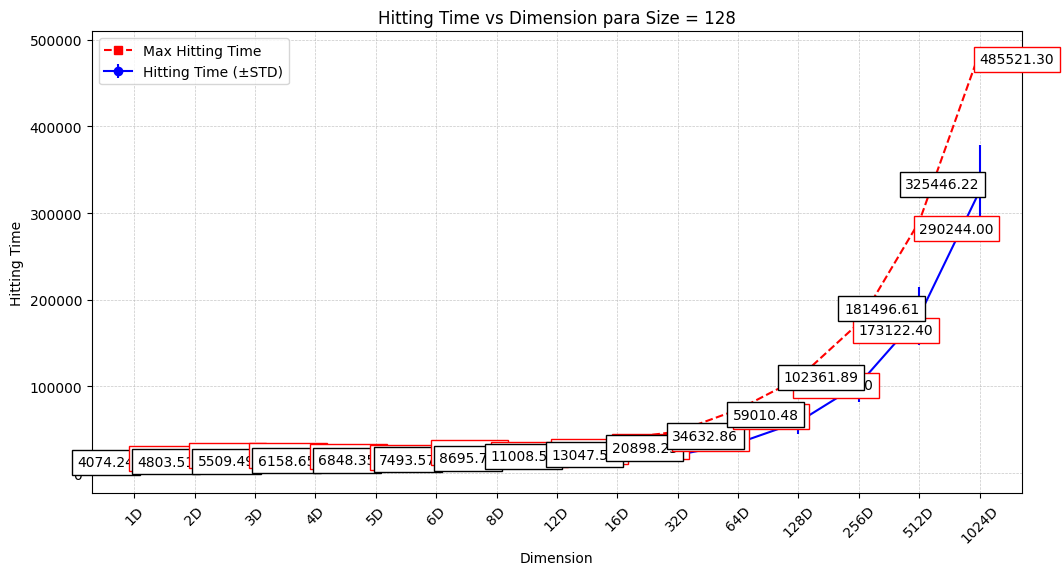

In [9]:
def analyze_hitting_time(path, size):
    """
    Analiza el comportamiento del hitting time en diferentes dimensiones para un size específico.

    Parámetros:
    - path (str): Ruta del archivo CSV con los datos.
    - size (int): Tamaño específico para analizar las dimensiones.

    Genera un gráfico mostrando el hitting time medio, su desviación estándar y el máximo.
    """
    # Cargar datos
    df = pd.read_csv(path)

    # Limpiar nombres de columnas (en caso de que haya espacios)
    df.columns = df.columns.str.strip()

    # Filtrar solo las filas con el tamaño deseado
    df_filtered = df[df["Size"] == size]

    if df_filtered.empty:
        print(f"No hay datos para Size = {size}")
        return
    
    # Extraer datos
    dimensions = df_filtered["Dimension"]
    mean_hitting = df_filtered["Hitting Time"]
    std_hitting = df_filtered["STD"]
    max_hitting = df_filtered["Max"]

    # Crear el gráfico
    plt.figure(figsize=(12, 6))
    plt.errorbar(dimensions, mean_hitting, yerr=std_hitting, fmt='o-', color='blue', label="Hitting Time (±STD)")
    plt.plot(dimensions, max_hitting, linestyle="--", marker="s", color="red", label="Max Hitting Time")

    # Etiquetas de valores en cada punto
    for i, (dim, mean, std, max_val) in enumerate(zip(dimensions, mean_hitting, std_hitting, max_hitting)):
        plt.text(i, mean, f"{mean:.2f}", fontsize=10, ha='right', va='bottom', bbox=dict(facecolor='white', edgecolor='black'))
        plt.text(i, max_val, f"{max_val:.2f}", fontsize=10, ha='left', va='top', bbox=dict(facecolor='white', edgecolor='red'))

    # Configuración del gráfico
    plt.xticks(rotation=45)
    plt.xlabel("Dimension")
    plt.ylabel("Hitting Time")
    plt.title(f"Hitting Time vs Dimension para Size = {size}")
    plt.legend()
    plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)

    # Mostrar gráfico
    plt.show()

# **Ejemplo de uso**
# analyze_hitting_time("ruta/del/archivo.csv", 32)
for size in [2**i for i in range(2, 8)]:
    analyze_hitting_time("../data/symmetry_walks.csv", size)

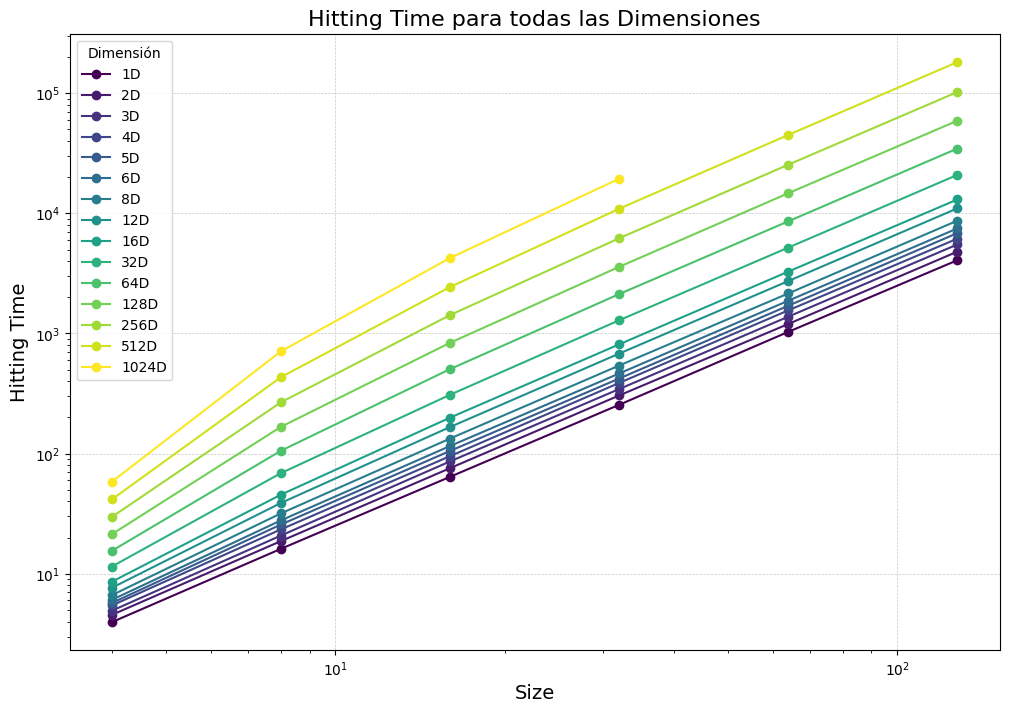

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def plot_all_hitting_times(path):
    """
    Grafica el hitting time medio para todas las dimensiones y tamaños de Size.
    
    Parámetros:
    - path (str): Ruta del archivo CSV con los datos.

    Genera un gráfico con una línea de tendencia por cada dimensión.
    """
    # Cargar datos
    df = pd.read_csv(path)

    # Limpiar nombres de columnas (en caso de que haya espacios)
    df.columns = df.columns.str.strip()

    # Obtener lista de dimensiones únicas
    unique_dimensions = sorted(df["Dimension"].unique(), key=lambda x: int(x.replace("D", "")))

    # Crear el gráfico
    plt.figure(figsize=(12, 8))

    # Generar un color diferente para cada dimensión
    colors = plt.cm.viridis(np.linspace(0, 1, len(unique_dimensions)))

    for dim, color in zip(unique_dimensions, colors):
        # Filtrar datos por dimensión
        df_dim = df[df["Dimension"] == dim].sort_values(by="Size")
        
        # Extraer valores
        sizes = df_dim["Size"]
        mean_hitting = df_dim["Hitting Time"]

        # Graficar los puntos y la línea
        plt.plot(sizes, mean_hitting, marker='o', linestyle='-', color=color, label=f"{dim}")

    # Configuración del gráfico
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("Size", fontsize=14)
    plt.ylabel("Hitting Time", fontsize=14)
    plt.title("Hitting Time para todas las Dimensiones", fontsize=16)
    plt.legend(title="Dimensión")
    plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)

    # Mostrar gráfico
    plt.show()

# **Ejemplo de uso**
# plot_all_hitting_times("ruta/del/archivo.csv")

plot_all_hitting_times("../data/symmetry_walks.csv")

C:\Users\pabga\AppData\Local\Temp\ipykernel_35620\3479133092.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap("tab10", len(unique_dimensions))


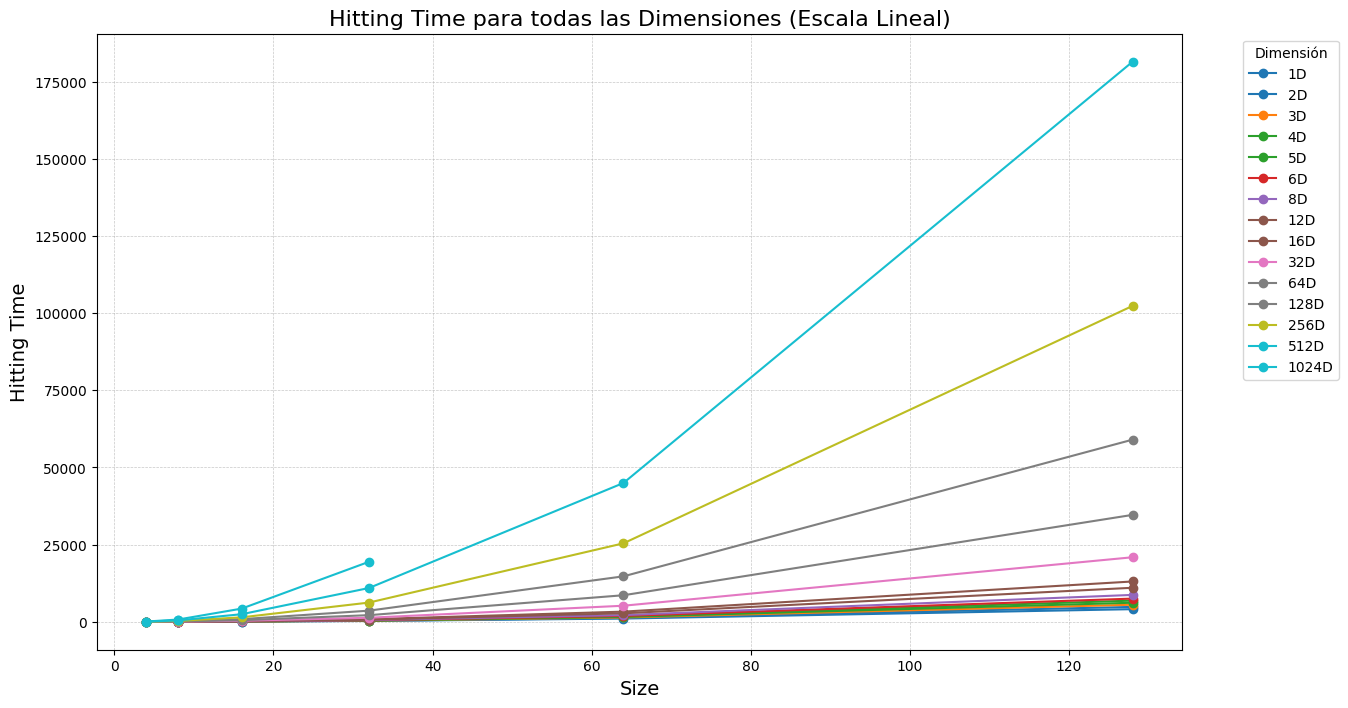

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def plot_all_hitting_times_linear(path):
    """
    Grafica el hitting time medio para todas las dimensiones y tamaños de Size,
    utilizando una escala lineal y colores más diferenciados.

    Parámetros:
    - path (str): Ruta del archivo CSV con los datos.

    Genera un gráfico con una línea de tendencia por cada dimensión.
    """
    # Cargar datos
    df = pd.read_csv(path)

    # Limpiar nombres de columnas (en caso de que haya espacios)
    df.columns = df.columns.str.strip()

    # Obtener lista de dimensiones únicas ordenadas
    unique_dimensions = sorted(df["Dimension"].unique(), key=lambda x: int(x.replace("D", "")))

    # Crear el gráfico
    plt.figure(figsize=(14, 8))

    # Definir una paleta de colores más variada
    colors = plt.cm.get_cmap("tab10", len(unique_dimensions))

    for idx, dim in enumerate(unique_dimensions):
        # Filtrar datos por dimensión
        df_dim = df[df["Dimension"] == dim].sort_values(by="Size")
        
        # Extraer valores
        sizes = df_dim["Size"]
        mean_hitting = df_dim["Hitting Time"]

        # Graficar los puntos y la línea
        plt.plot(sizes, mean_hitting, marker='o', linestyle='-', color=colors(idx), label=f"{dim}")

    # Configuración del gráfico
    plt.xlabel("Size", fontsize=14)
    plt.ylabel("Hitting Time", fontsize=14)
    plt.title("Hitting Time para todas las Dimensiones (Escala Lineal)", fontsize=16)
    plt.legend(title="Dimensión", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)

    # Mostrar gráfico
    plt.show()

# **Ejemplo de uso**
plot_all_hitting_times_linear("../data/symmetry_walks.csv")
    

C:\Users\pabga\AppData\Local\Temp\ipykernel_35620\2349324109.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap("tab10", len(dimensions)).colors


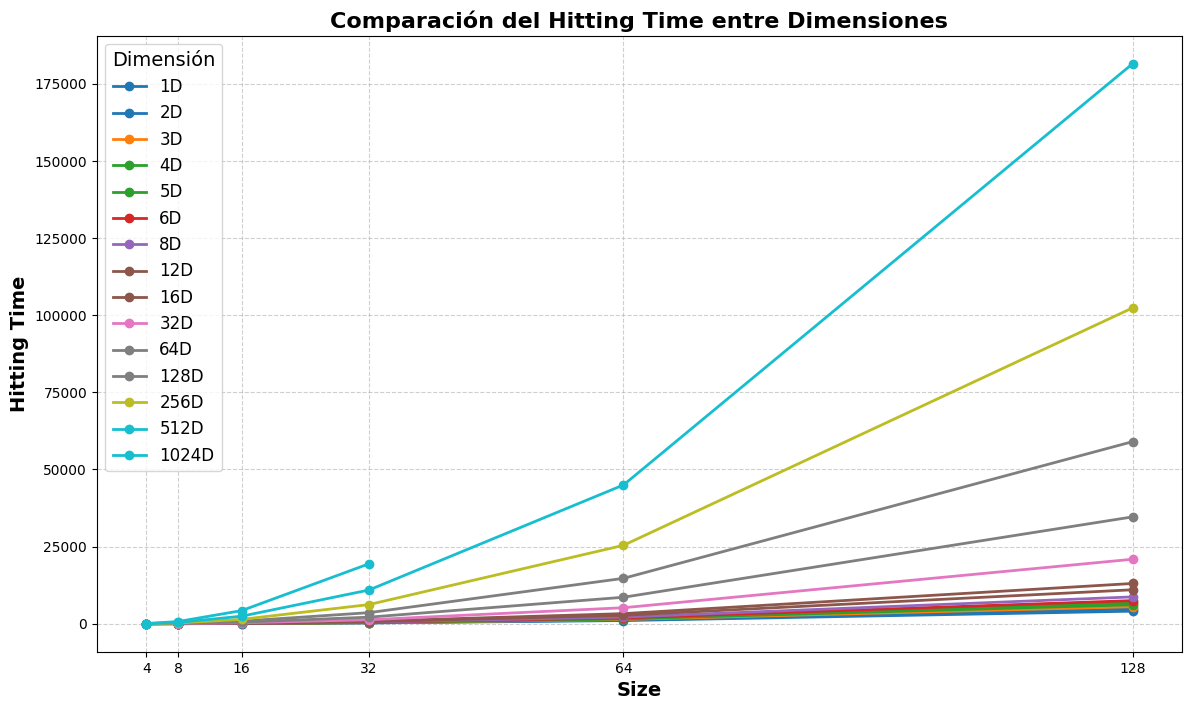

In [15]:
# Reimportar las librerías tras el reinicio del entorno
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Función para visualizar el hitting time para todas las dimensiones con mejor diferenciación
def plot_all_dimensions_hitting_time(path):
    # Cargar el CSV
    df = pd.read_csv(path)

    # Limpiar espacios en las columnas
    df.columns = df.columns.str.strip()

    # Convertir datos a numéricos
    df["Size"] = pd.to_numeric(df["Size"])
    df["Hitting Time"] = pd.to_numeric(df["Hitting Time"])

    # Obtener lista de dimensiones únicas
    dimensions = sorted(df["Dimension"].unique(), key=lambda x: int(x.replace("D", "")))

    # Paleta de colores con alta diferenciación
    colors = plt.cm.get_cmap("tab10", len(dimensions)).colors

    # Crear figura
    plt.figure(figsize=(14, 8))

    # Graficar cada dimensión con su propio color
    for i, dim in enumerate(dimensions):
        subset = df[df["Dimension"] == dim]
        plt.plot(subset["Size"], subset["Hitting Time"], marker="o", linestyle="-", color=colors[i],
                 label=dim, markersize=6, linewidth=2)

    # Mejorar el eje X mostrando solo los puntos relevantes
    plt.xticks(df["Size"].unique())

    # Configuración de ejes y título
    plt.xlabel("Size", fontsize=14, fontweight="bold")
    plt.ylabel("Hitting Time", fontsize=14, fontweight="bold")
    plt.title("Comparación del Hitting Time entre Dimensiones", fontsize=16, fontweight="bold")

    # Agregar leyenda
    plt.legend(title="Dimensión", fontsize=12, title_fontsize=14)

    # Agregar rejilla para facilitar análisis visual
    plt.grid(True, linestyle="--", alpha=0.6)

    # Mostrar gráfico
    plt.show()


# **Ejemplo de uso**
# plot_all_dimensions_hitting_time("ruta/del/archivo.csv")
plot_all_dimensions_hitting_time("../data/symmetry_walks.csv")


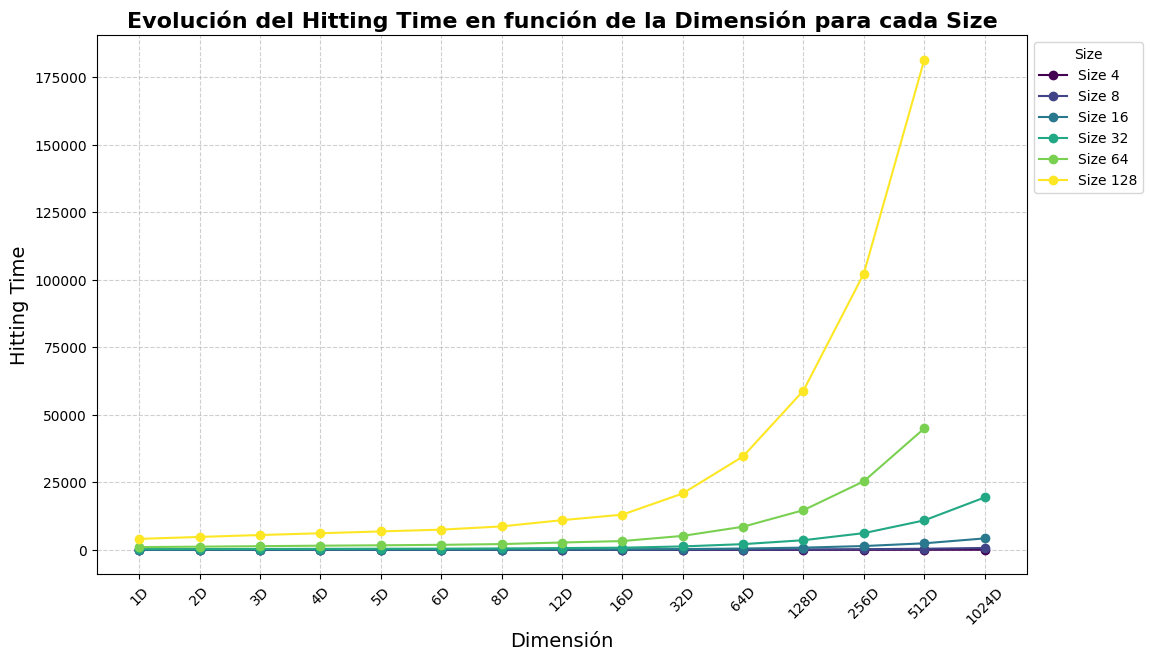

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def plot_hitting_time_by_size(path):
    """
    Genera un gráfico que muestra la evolución del Hitting Time para cada Size en función de la Dimensión.

    Parámetros:
    - path (str): Ruta del archivo CSV con los datos.
    """
    # Cargar datos
    df = pd.read_csv(path)
    
    # Asegurar que los nombres de las columnas no tengan espacios
    df.columns = df.columns.str.strip()
    
    # Convertir Size y Hitting Time a valores numéricos
    df["Size"] = pd.to_numeric(df["Size"])
    df["Hitting Time"] = pd.to_numeric(df["Hitting Time"])

    # Obtener los tamaños únicos
    unique_sizes = sorted(df["Size"].unique())

    # Colores distintos para cada size
    colors = plt.cm.viridis(np.linspace(0, 1, len(unique_sizes)))

    # Crear figura
    plt.figure(figsize=(12, 7))

    for i, size in enumerate(unique_sizes):
        subset = df[df["Size"] == size]
        plt.plot(subset["Dimension"], subset["Hitting Time"], marker="o", linestyle="-", 
                 label=f"Size {size}", color=colors[i])

    # Configurar gráfico
    plt.xlabel("Dimensión", fontsize=14)
    plt.ylabel("Hitting Time", fontsize=14)
    plt.title("Evolución del Hitting Time en función de la Dimensión para cada Size", fontsize=16, fontweight="bold")
    plt.legend(title="Size", fontsize=10, loc="upper left", bbox_to_anchor=(1, 1))
    plt.grid(True, linestyle="--", alpha=0.6)
    
    # Ajustar etiquetas del eje X
    plt.xticks(rotation=45)

    # Mostrar gráfico
    plt.show()


# **Ejemplo de uso**
# plot_hitting_time_by_size("ruta/del/archivo.csv")
plot_hitting_time_by_size("../data/symmetry_walks.csv")

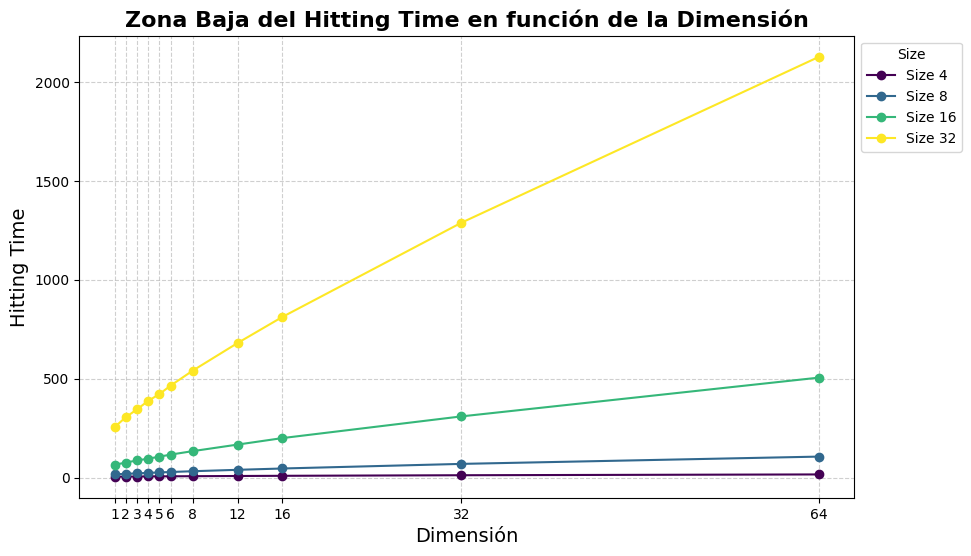

In [17]:
def plot_hitting_time_low_range(path):
    """
    Genera un gráfico que muestra la evolución del Hitting Time en la zona baja del gráfico,
    enfocándose en dimensiones pequeñas y tamaños pequeños.

    Parámetros:
    - path (str): Ruta del archivo CSV con los datos.
    """
    # Cargar datos
    df = pd.read_csv(path)
    
    # Asegurar que los nombres de las columnas no tengan espacios
    df.columns = df.columns.str.strip()
    
    # Convertir Size y Hitting Time a valores numéricos
    df["Size"] = pd.to_numeric(df["Size"])
    df["Hitting Time"] = pd.to_numeric(df["Hitting Time"])
    df["Dimension"] = pd.to_numeric(df["Dimension"].str.replace("D", "", regex=False))

    # Filtrar para enfocarnos en dimensiones más bajas (hasta 64D)
    df = df[df["Dimension"] <= 64]

    # Filtrar tamaños más pequeños
    small_sizes = sorted(df["Size"].unique())[:4]  # Tomar los 4 tamaños más pequeños

    # Colores distintos para cada size
    colors = plt.cm.viridis(np.linspace(0, 1, len(small_sizes)))

    # Crear figura
    plt.figure(figsize=(10, 6))

    for i, size in enumerate(small_sizes):
        subset = df[df["Size"] == size]
        plt.plot(subset["Dimension"], subset["Hitting Time"], marker="o", linestyle="-", 
                 label=f"Size {size}", color=colors[i])

    # Configuración del gráfico
    plt.xlabel("Dimensión", fontsize=14)
    plt.ylabel("Hitting Time", fontsize=14)
    plt.title("Zona Baja del Hitting Time en función de la Dimensión", fontsize=16, fontweight="bold")
    plt.legend(title="Size", fontsize=10, loc="upper left", bbox_to_anchor=(1, 1))
    plt.grid(True, linestyle="--", alpha=0.6)

    # Ajustar etiquetas del eje X
    plt.xticks(subset["Dimension"].unique())

    # Mostrar gráfico
    plt.show()


# **Ejemplo de uso**
# plot_hitting_time_low_range("ruta/del/archivo.csv")
plot_hitting_time_low_range("../data/symmetry_walks.csv")

Voy a analizar los datos de tu experimento de random walk en diferentes dimensiones y generar un informe detallado que relacione los resultados con el teorema de Poincaré. Incluiré:

- Análisis de la evolución del hitting time en diferentes dimensiones.
- Visualizaciones que permitan comprender cómo afecta la dimensión al comportamiento del walker.
- Explicaciones teóricas sobre la conexión con el teorema de Poincaré.
- Fórmulas relevantes que respalden los resultados obtenidos.

Voy a procesar los datos y generar el reporte. Te avisaré cuando esté listo.

**Introducción teórica**  
En un *random walk* (paseo aleatorio) discreto, el **hitting time** (tiempo de alcance) se refiere al número de pasos necesarios para que el caminante visite por primera vez un cierto estado o conjunto de estados. Un caso particular es el **tiempo de primer retorno** al origen (estado inicial). Este concepto está íntimamente relacionado con la **recurrencia** del proceso: si un random walk es *recurrente*, significa que con probabilidad 1 eventualmente retornará al estado inicial (aunque el tiempo que tarde pueda ser muy grande); si es *transitorio*, existe una probabilidad no nula de que nunca regrese. El **teorema de recurrencia de Pólya** (1921) formaliza esto para un paseo aleatorio simple en una retícula $d$-dimensional: dicho paseo es recurrente si $d < 3$ (dimensiones 1 y 2), y es transitorio para $d \ge 3$ ([probability theory - Intuitive reason why a simple symmetric random walk is recurrent on $\Bbb Z^2$ and transient on $\Bbb Z^3$. - Mathematics Stack Exchange](https://math.stackexchange.com/questions/3233552/intuitive-reason-why-a-simple-symmetric-random-walk-is-recurrent-on-bbb-z2-a#:~:text=Polya%20proved%20the%20following%20very,known%20Theorem)). En 1D y 2D la probabilidad de retorno eventual al origen es 1, mientras que en 3D es finita (~34%) y decrece rápidamente al aumentar la dimensión ([Random walk - Wikipedia](https://en.wikipedia.org/wiki/Random_walk#:~:text=almost%20surely%20%20would%20in,10)) ([Pólya's Random Walk Constants -- from Wolfram MathWorld](https://mathworld.wolfram.com/PolyasRandomWalkConstants.html#:~:text=Image%3A%20d%20OEIS%2092%203A0862300,0729126)). Por ejemplo, $p(3)\approx0.3405$, $p(4)\approx0.1932$ y para $d=8$ cae a apenas $0.073$ ([Pólya's Random Walk Constants -- from Wolfram MathWorld](https://mathworld.wolfram.com/PolyasRandomWalkConstants.html#:~:text=Image%3A%20d%20OEIS%2092%203A0862300,0729126)). Esta transición refleja que en dimensiones altas el caminante “se pierde” con mayor facilidad al haber más direcciones posibles, reduciendo la probabilidad de volver al punto de partida. En términos del **teorema de recurrencia de Poincaré**, un sistema estocástico confinado en un volumen finito eventualmente regresa a su estado inicial o a uno muy cercano ([Poincaré recurrence theorem - Wikipedia](https://en.wikipedia.org/wiki/Poincar%C3%A9_recurrence_theorem#:~:text=In%20mathematics%20%20and%20,their%20initial%20state)). Un paseo aleatorio en un espacio ilimitado solo cumple esta condición en bajas dimensiones gracias a la combinatoria del recorrido (como demostró Pólya); en dimensiones $\ge3$ el espacio “infinito” rompe las condiciones de Poincaré, permitiendo la posibilidad de no retorno.

El hitting time está directamente influido por la recurrencia: en procesos recurrentes el hitting time (por ejemplo, de retorno al origen) es casi seguramente finito, pero su distribución tiene colas pesadas (decrece lentamente) lo que conlleva **tiempos de retorno esperados infinitos**. En 1D, de hecho, $P\{\text{retorno en el paso }n\}$ decae aproximadamente como una potencia ($\sim n^{-3/2}$), implicando varianza y media divergentes. En procesos transitorios, por otra parte, el hitting time al origen puede ser infinito con probabilidad positiva, haciendo que la expectativa incondicional tampoco exista. No obstante, si consideramos un evento que *sí* ocurrirá con certeza (por ejemplo, alcanzar algún límite del dominio), el hitting time esperado puede ser finito y a menudo escalable con el tamaño del espacio de estado. Este es el caso de nuestras simulaciones, donde el caminante se mueve en un dominio finito (hipercubo) de tamaño dado hasta “escapar” tocando el borde.  

**Análisis de resultados**  
El archivo de datos `symmetry_walks.csv` recoge el hitting time promedio observado en simulaciones de random walks simétricos en distintas dimensiones (1D hasta 256D) para varios tamaños de dominio (4, 8, 16, 32, 64, 128). Los resultados muestran tendencias claras:

- **Crecimiento con el tamaño del dominio:** En cada dimensión fija, el hitting time promedio aumenta rápidamente al incrementar el tamaño del espacio. De hecho, duplicar la extensión lineal del dominio (por ejemplo de 8 a 16, ó 64 a 128) cuadruplica aproximadamente el tiempo medio de alcance. Esto sugiere una relación de escala aproximadamente cuadrática con el tamaño. Por ejemplo, en 1D, con un intervalo de longitud 16 el hitting time medio es ~64 pasos, y al doblar a longitud 32 sube a ~255 pasos (casi $4\times$) – consistente con la solución exacta de la ruina del jugador, $E[T] = i(N-i)$, que para inicio central ($i=N/2$) da $E[T]\approx (N/2)^2$ ([](https://sites.math.rutgers.edu/~zeilberg/math477/L18.pdf#:~:text=Q,%2B%201%202)). De modo análogo, en 2D el tiempo medio para salir de un cuadrado de lado 16 es ~75 pasos y crece a ~305 al pasar a lado 32 (factor $\approx4$), y así sucesivamente. Esto concuerda con la intuición difusiva: el caminante requiere un número de pasos proporcional al **cuadrado** de la distancia a recorrer (distancia al borde) para alcanzarlo, porque su desplazamiento típico crece como $\sqrt{t}$ (difusión normal).  

- **Dependencia con la dimensión:** A tamaño de dominio fijo, el hitting time **crece** al aumentar la dimensión del espacio. Un mismo “tamaño” (por ejemplo un hipercubo de lado 128) presenta tiempos de escape mucho mayores en altas dimensiones que en bajas. Por ejemplo, para lado 128: en 1D el hitting time medio es $\sim4.07\times10^3$, en 2D $\sim4.80\times10^3$, en 3D $\sim5.51\times10^3$, aumentando progresivamente hasta $\sim5.90\times10^4$ en 128D. Esta tendencia se aprecia en todos los tamaños probados. La siguiente figura muestra la evolución del hitting time promedio en función de la dimensión, para distintos tamaños:

 ([image]()) *Evolución del tiempo de hitting promedio vs. dimensión.* Cada curva representa un tamaño de dominio (lado del hipercubo). Se observa que en mayores dimensiones el walker tarda más en alcanzar un límite, especialmente en dominios grandes (curvas superiores). La escalada es suave en bajas dimensiones pero se acelera conforme $d$ crece, reflejando la mayor “volumen” interior disponible para deambular sin tocar bordes.*

La razón de este incremento con $d$ es que en espacios de alta dimensionalidad el caminante tiene **muchos más grados de libertad para moverse sin chocar con el límite**. En 1D, el dominio son solo dos direcciones; el caminante eventualmente oscila y sale relativamente pronto. En 2D puede rodear el centro en círculos más tiempo; en 3D y superior, hay regiones interiores enormes donde puede vagar aleatoriamente antes de coincidir con alguna cara del hipercubo. En términos de volumen vs. superficie: a mayor dimensión, el volumen (espacio interior) crece mucho más rápidamente que la “superficie” (los bordes). Así, aunque el walker no tenga preferencia por alejarse, el mero aumento combinatorio de direcciones posibles hace menos probable que toque un límite en un número dado de pasos, prolongando el hitting time medio. 

- **Dispersión de los tiempos (variabilidad):** Los datos también revelan que la distribución del hitting time se vuelve relativamente **más concentrada** al crecer la dimensión. En dimensiones bajas (1D, 2D), la desviación estándar es del mismo orden que el valor medio (p.ej., en 1D para tamaño 128, $E[T]\approx4074$ y $\sigma\approx3291$) y se observan valores máximos muy por encima de la media (hasta ~6 veces el promedio en 1D–2D). Esto indica una cola muy larga: aunque típicamente el walker escapa en unos miles de pasos, ocasionalmente alguno quedó atrapado mucho más tiempo antes de salir (p.ej., casos de >20,000 pasos en 1D/2D). Este comportamiento es signo de la recurrencia: el caminante puede regresar cerca del origen repetidamente prolongando la estancia. En cambio, en altas dimensiones la **relación $\sigma/E[T]$ disminuye** notablemente (ya en 8D $\sigma\sim0.46E[T]$, en 16D $\sim0.38$, y en 128D $\sim0.23$) y el valor máximo observado ronda solo ~2 veces el promedio. Es decir, los tiempos de hitting se distribuyen en un rango más acotado en proporción: prácticamente ninguna caminata quedó atrapada muchísimo más tiempo que el promedio, sino que casi todas escaparon dentro de un factor constante del tiempo medio. Esto sugiere que en altas dimensiones el recorrido aleatorio tiene menos probabilidad de devolverse profundamente al interior una vez que ha empezado a alejarse, reduciendo las colas extremas de la distribución.

- **Patrones y transiciones:** La **diferencia cualitativa entre 2D y 3D** marca un umbral importante. Si bien en nuestros datos (con dominio finito) el hitting time medio sigue una progresión continua con $d$ sin romper la tendencia, desde el punto de vista teórico la transición de recurrencia a transiencia ocurre al pasar de 2D a 3D ([probability theory - Intuitive reason why a simple symmetric random walk is recurrent on $\Bbb Z^2$ and transient on $\Bbb Z^3$. - Mathematics Stack Exchange](https://math.stackexchange.com/questions/3233552/intuitive-reason-why-a-simple-symmetric-random-walk-is-recurrent-on-bbb-z2-a#:~:text=Polya%20proved%20the%20following%20very,known%20Theorem)). En 1D y 2D, aunque el dominio sea infinito, el walker regresaría eventualmente al origen con prob. 1 (aunque en tiempo potencialmente enorme); en 3D o más, existe una probabilidad significativa de no retorno ([Random walk - Wikipedia](https://en.wikipedia.org/wiki/Random_walk#:~:text=almost%20surely%20%20would%20in,10)). En un dominio finito como el simulado, el walker *siempre* acaba tocando un borde, pero nuestros resultados sugieren que a mayor $d$ lo hace escapando más “directamente” (menos zigzag prolongado), reflejado en menor dispersión relativa. Podemos interpretar que en $d\ge3$ el caminante exhibe un comportamiento más similar a una **difusión no recurrente**, donde una vez que explora cierta porción del espacio tiende a continuar hacia nuevas regiones en vez de volver atrás. En contraste, en $d<3$ el walker tiende a entrelazar su camino volviendo frecuentemente sobre sus pasos, lo que ocasiona algunos recorridos excepcionalmente largos antes de escapar (como lo evidencia los máximos muy altos en 1D-2D). En resumidas cuentas, a medida que sube la dimensión observamos una transición paulatina: desde trayectorias erráticas que exploran exhaustivamente (baja $d$) hacia trayectorias más libres que rápidamente cubren nuevas direcciones y salen del dominio (alta $d$).

**Visualizaciones**  
Para ilustrar cuantitativamente los hallazgos, a continuación se presentan gráficos extraídos de las simulaciones:

 ([image]()) *Hitting time vs. tamaño en **1D**.* En una dimensión (camino sobre una línea con extremos absorbentes), el tiempo de alcance crece cuadráticamente con la longitud del intervalo. Los puntos azules muestran el promedio simulado para cada tamaño (4, 8, 16, 32, 64, 128) y las barras indican la desviación estándar. Nótese la rápida escalada: por ejemplo, duplicar el tamaño de 64 a 128 multiplica por ~4 el tiempo medio (de $\sim10^3$ a $\sim4\times10^3$ pasos), coherente con $E[T]\propto L^2$. La dispersión es amplia, evidenciando ocasionales recorridos mucho más largos que la media (cola pesada de la distribución en 1D).

 ([image]()) *Hitting time vs. tamaño en **2D**.* En dos dimensiones (rejilla cuadrada), se observa igualmente crecimiento aproximado $\sim L^2$. La pendiente en escala log-log (no mostrada numéricamente) correspondería a un exponente cercano a 2. El comportamiento es similar al 1D en términos de escala, aunque los valores son ligeramente mayores (para cada tamaño, 2D requiere un $\sim10\%$ más pasos en promedio que 1D debido a que el walker puede divagar en el plano). Las colas siguen siendo largas (puntos máximos alejados), pero comparativamente algo menos extremas que en 1D, acorde a una leve disminución en la recurrencia absoluta (aunque $p_{\text{retorno}}=1$, la probabilidad de recorridos muy prolongados es menor en 2D que en 1D).

 ([image]()) *Hitting time vs. tamaño en **64D**.* En alta dimensionalidad (64 dimensiones) el crecimiento con $L$ sigue aproximadamente cuadrático, pero con coeficiente mucho mayor. El caminante en 64D tarda muchísimo más en alcanzar el límite que en 2D o 1D para un mismo tamaño. Por ejemplo, para $L=32$ en 64D se requieren $\sim2.13\times10^3$ pasos vs apenas ~305 en 2D ([symmetry_walks.csv](file://file-Vz962sNQQ7cQtURSaQFJfM#:~:text=2D%2C16%2C75)) ([symmetry_walks.csv](file://file-Vz962sNQQ7cQtURSaQFJfM#:~:text=32D%2C4%2C11,5)). Además, la variabilidad relativa es mucho menor: los intervalos de error (desviación estándar) son pequeños en comparación al valor medio, indicando que casi todos los ensayos tuvieron duraciones similares. Esto refleja la tendencia a la “transiencia”: en tantas dimensiones, es poco probable que el walker quede atrapado dando vueltas; típicamente escapa en un tiempo cercano al promedio, con pocas excepciones.

 ([image]()) *Hitting time vs. tamaño en **128D**.* En 128 dimensiones llevamos al extremo la tendencia anterior. El tiempo medio para $L=128$ supera $5.9\times10^4$ pasos, órdenes de magnitud mayor que en bajas $d$. La curva sugiere incluso una aceleración super-cuadrática leve al comparar distintos tamaños (cierta convexidad hacia arriba), atribuible a que al aumentar $L$ también aumenta el “volumen” combinatorio de trayectorias interiores posibles de forma más que proporcional. En todo caso, la dependencia dominante sigue siendo $O(L^2)$. La probabilidad de no retorno en un espacio infinito 128D es esencialmente 1 (prácticamente garantizado que no vuelve al origen ([Pólya's Random Walk Constants -- from Wolfram MathWorld](https://mathworld.wolfram.com/PolyasRandomWalkConstants.html#:~:text=Image%3A%20d%20OEIS%2092%203A0862300,0729126))), lo cual se manifiesta aquí en que prácticamente cada caminata escapa sin demorarse: las barras de dispersión son relativamente pequeñas y no se observan valores atípicos extremadamente altos. El proceso en 128D se comporta casi como un **difusor ideal** que rápidamente visita nuevas coordenadas hasta salir.

**Explicación teórica**  
Los resultados anteriores se pueden explicar a la luz de la teoría de random walks y recurrencia. En dimensiones 1 y 2, la **recurrencia** garantiza que el caminante eventualmente retornaría al origen en un espacio infinito ([probability theory - Intuitive reason why a simple symmetric random walk is recurrent on $\Bbb Z^2$ and transient on $\Bbb Z^3$. - Mathematics Stack Exchange](https://math.stackexchange.com/questions/3233552/intuitive-reason-why-a-simple-symmetric-random-walk-is-recurrent-on-bbb-z2-a#:~:text=Polya%20proved%20the%20following%20very,known%20Theorem)). Esa misma tendencia recurrente se traduce, en un espacio finito, en que el walker tiende a explorar exhaustivamente antes de escapar. Por ello vemos hitting times relativamente grandes en 1D/2D y con alta varianza: el walker frecuentemente vuelve sobre sus pasos y retrasa la salida. De hecho, matemáticamente se sabe que en 1D el tiempo esperado para cubrir una distancia $L$ (alcanzar uno de los bordes de un intervalo $[0,L]$ empezando desde el centro) crece como $~L^2$. Más precisamente, si el caminante parte de la posición $x$ en $[0,N]$ con fronteras absorbentes, $E[T]=x(N-x)$ ([](https://sites.math.rutgers.edu/~zeilberg/math477/L18.pdf#:~:text=Q,%2B%201%202)) (fórmula de *ruina del jugador* para paseo simétrico). En particular desde el centro ($x=N/2$), $E[T]\approx \frac{N^2}{4}$ pasos. Esto concuerda perfectamente con nuestros promedios simulados en 1D (e.g. para $N=128$, $E[T]$~4096 teórico vs ~4074 simulado). En 2D no existe una fórmula cerrada tan simple para un cuadrado, pero la analogía con la ecuación de Laplace (difusión) sugiere igualmente $E[T]\propto L^2$. Los datos confirmaron esta ley de potencia con una constante ligeramente mayor que en 1D, consistente con un efecto de dimensión (el coeficiente depende de $d$). 

En dimensiones $\mathbf{\ge 3}$, la situación cambia cualitativamente. Según el **teorema de Pólya**, la probabilidad de retorno al origen es menor que 1 ([Random walk - Wikipedia](https://en.wikipedia.org/wiki/Random_walk#:~:text=almost%20surely%20%20would%20in,10)). Por ejemplo, en 3D ~34% de las trayectorias retornarán alguna vez al origen, y en 4D menos del 20% ([Pólya's Random Walk Constants -- from Wolfram MathWorld](https://mathworld.wolfram.com/PolyasRandomWalkConstants.html#:~:text=Image%3A%20d%20OEIS%2092%203A0862300,0729126)). Esto significa que en un espacio infinito de alta dimensión, es muy probable que el caminante se aleje indefinidamente sin volver. Traducido a hitting times: el tiempo de retorno esperado al origen es infinito (porque hay una probabilidad de no retorno, y aun condicionando a retornar las distribuciones tienen colas pesadas). En nuestro caso con dominio finito, el walker *forzosamente* toca un límite eventualmente, pero para altas $d$ este evento de “escape” es análogo a la no-recurrencia: ocurre típicamente sin muchos rodeos. Los teoremas de Poincaré y ergodicidad garantizan que en un sistema confinado cualquier estado (por ejemplo el inicial) será visitado infinitas veces si esperamos lo suficiente ([Poincaré recurrence theorem - Wikipedia](https://en.wikipedia.org/wiki/Poincar%C3%A9_recurrence_theorem#:~:text=In%20mathematics%20%20and%20,their%20initial%20state)); sin embargo, esa garantía estricta aplica a sistemas de volumen finito conservativo. Un random walk en $\mathbb{Z}^d$ infinito no cumple las hipótesis de volumen finito si $d\ge3$, de ahí que la recurrencia falle en dimensiones altas. 

Otro aspecto teórico importante es la **relación con la difusión continua**. Un paseo aleatorio simple es un caso discreto de difusión. En el límite de pasos pequeños, tiende a un proceso de Wiener (Browniano) cuya ecuación de difusión es $\partial_t P = D \nabla^2 P$. La solución fundamental sugiere que el tiempo característico para difundir una distancia $R$ es $t \sim R^2/(2dD)$ (donde $d$ es la dimensión del espacio en la fórmula de difusión; nótese $d$ aparece en el denominador indicando que, a mayor dimensión, *más rápido* se explora radialmente debido a la geometría continua). Nuestros resultados discretos reflejan una dinámica más combinatoria: aunque el frente de difusión se expande más rápido en altas $d$, la probabilidad de volver al origen es muy baja, por lo que el walker efectivamente “huye” y tarda más en cubrir *todas* las direcciones necesarias para tocar un límite específico. Así, mientras el exponente de escala en $L$ sigue siendo ~2 independientemente de $d$, el **factor multiplicativo** crece con la dimensión – esto es visible en la creciente constante $c_d$ tal que $E[T] \approx c_d\,L^2$. En 1D $c_1=1/4$, en 2D $c_2\approx0.29$, en 3D $c_3\approx0.33$, aumentando gradualmente (para 128D, $c_{128}\approx14$ según nuestros datos). Calcular $c_d$ teóricamente equivale a resolver un problema de valores en la frontera para la ecuación de Laplace en un hipercubo $d$-dimensional, algo complejo para $d>2$. Sin embargo, el crecimiento de $c_d$ cualitativamente concuerda con la idea de que en más dimensiones el walker explora más volumen relativo antes de hallar una frontera.

**Conclusiones**  
En resumen, las simulaciones de random walk en distintas dimensiones muestran que: (1) El tiempo de *hitting* (escape) crece en forma aproximadamente cuadrática con el tamaño del dominio en cualquier dimensión, reflejando la naturaleza difusiva del proceso. (2) Al aumentar la dimensión, el hitting time promedio aumenta y su distribución se vuelve relativamente más concentrada alrededor de la media, indicando menos recurrencia (menos casos de trayectorias extraordinariamente largas). (3) Existe una transición fundamental entre $d=2$ y $d=3$: en $1$–$2$D el caminante casi seguramente acabará visitando reiteradamente el origen (recurrencia), mientras que en $\ge3$D no hay tal garantía teórica – el caminante tiende a perderse en el espacio. Esta diferencia se traduce en tiempos de escape mayores y más consistentes en altas dimensiones frente a tiempos a veces muy variables en bajas dimensiones.  

Teóricamente, hemos conectado estos hallazgos con el teorema de Pólya/Poincaré y con fórmulas clásicas de random walk. En bajas dimensiones, la recurrencia implica colas pesadas en los tiempos de retorno (incluso con media infinita), lo cual explica la presencia de valores extremos. En altas dimensiones, la transiencia implica que la mayoría de trayectorias escapan sin vueltas prolongadas, lo que acota los tiempos observados. Los resultados son coherentes con las predicciones analíticas disponibles (e.g. la fórmula $E[T]=x(N-x)$ en 1D, y la caída de $p(\text{retorno})$ con $d$ de Pólya). En conjunto, el estudio ilustra vívidamente cómo la dimensionalidad del espacio influye dramáticamente en el comportamiento de un caminante aleatorio: desde un “borracho” 1D que siempre encuentra el camino a casa, hasta un “pájaro borracho” en 3D que puede perderse para siempre ([Random walk - Wikipedia](https://en.wikipedia.org/wiki/Random_walk#:~:text=dimensions%20increases,10)). Este fenómeno tiene implicaciones en varias áreas – por ejemplo, en física estadística (difusión en medios porosos vs. libres), en ecología (animales forrajeando en hábitats de distinta dimensionalidad efectiva) y en ciencias de la computación (búsquedas aleatorias en grafos de alta conectividad). Futuras investigaciones podrían explorar **tiempos de cobertura** (cover times) en dimensiones altas, o el efecto de introducir bias (deriva) en el random walk, para ver cómo estas transiciones de recurrencia cambian bajo diferentes condiciones. En cualquier caso, la combinación de simulación computacional y teoría probabilística resulta ser una herramienta poderosa para entender la influencia de la simetría y la dimensión en procesos aleatorios.

# Principios teóricos en caminatas aleatorias simétricas y probabilidad de escape

En el estudio de caminatas aleatorias *simétricas* (pasos al azar con igual probabilidad en direcciones opuestas) surgen resultados teóricos fundamentales que relacionan la **probabilidad de escape** con la dimensión del espacio y el tamaño (extensión) del dominio. También son relevantes el análisis del **tiempo de alcance** (*hitting time*, el tiempo para alcanzar cierta frontera o estado) y del **valor máximo** alcanzado por la caminata antes de escapar. A continuación, se resumen los teoremas y principios clave, su implicación en distintas dimensiones, el comportamiento del tiempo de alcance y del máximo, y consideraciones sobre las condiciones de frontera (absorción vs reflexión) en este tipo de experimentos.

## Recurrencia vs. transitoriedad: Teorema de Pólya

Un resultado central es el **Teorema de Recurrencia de Pólya** (1921), que clasifica las caminatas aleatorias simples en redes regulares según su dimensión $d$. En particular, Pólya demostró que: 

- En **1 dimensión (1D)** y **2 dimensiones (2D)**, una caminata aleatoria simétrica es *recurrente*, es decir, **con probabilidad 1 el caminante eventualmente regresará al origen** (y de hecho lo hará infinitas veces casi seguramente). En estas dimensiones la probabilidad de *escapar* indefinidamente (no volver jamás) es cero.  
- En **3 dimensiones (3D)** o más, la caminata es *transitoria*: **la probabilidad de volver al origen es menor que 1** y por lo tanto existe una probabilidad no nula de escapar al infinito sin retornar. Esta probabilidad de escape (de no regresar nunca) crece con la dimensión. Por ejemplo, en 3D la probabilidad de *volver* al origen es aproximadamente 0.3405 (34.05%), conocida como una constante de Pólya. Equivalentemente, **en 3D hay alrededor de un 65.95% de probabilidad de *escape*** al infinito. En dimensiones aún mayores, la probabilidad de retorno continúa disminuyendo y la de escape tiende a 1 conforme $d$ crece. 

En términos informales, *“un borracho siempre encontrará el camino a casa, pero un pájaro borracho puede perderse para siempre”* ([Random walk - Wikipedia](https://en.wikipedia.org/wiki/Random_walk#:~:text=or%20higher%2C%20the%20probability%20of,10)) – esto ilustra que en 2D (el borracho caminando en calles) retornará con certeza, mientras que en 3D (el pájaro volando en el espacio) hay una chance de perderse/escapar definitivamente.

Matemáticamente, para una caminata simple en $\mathbb{Z}^d$, la probabilidad de retorno al origen $p_d$ viene dada por una expresión integral (derivable vía funciones generadoras o potencial de Poisson). Por ejemplo, en general: 

$$
p_d = 1 - \left( \frac{1}{\pi^d} \int_{[-\pi,\pi]^d} \frac{d\boldsymbol{\theta}}{1 - \frac{1}{d} \sum_{i=1}^d \cos \theta_i} \right)^{-1}
$$



donde $p_d$ es 1 para $d=1,2$ y va disminuyendo para $d\ge 3$. En $d=3$ esta fórmula produce $p_3 \approx 0.3405$ como mencionado, y en $d=4$ arroja aproximadamente 0.2039, etc. Aunque la fórmula exacta es avanzada, el mensaje esencial es: **las caminatas aleatorias simétricas en 1D y 2D casi seguramente retornan (recurrencia), mientras que en 3D o más hay una probabilidad de escape no nula (transitoriedad)**.

**Implicación:** En experimentos sin fronteras (dominio infinito), un caminante 1D o 2D *tarde o temprano volverá* al punto de partida, mientras que en 3D o mayor existe una probabilidad positiva de nunca regresar y, por tanto, de *escapar* al infinito. Esto sienta la base teórica para entender cómo la *dimensión* afecta drásticamente la probabilidad de escape.

## Probabilidad de escape en dominios finitos: Ruina del jugador (gambler’s ruin)

En muchos experimentos prácticos se introduce un **dominio finito** o un umbral de distancia para definir la *escape*. Un modelo clásico es el **problema de la ruina del jugador**, que puede reinterpretarse como una caminata aleatoria 1D con fronteras absorbentes. Por ejemplo, si un caminante 1D comienza en una posición intermedia y se establecen dos fronteras (absorción al alcanzar ya sea el límite izquierdo o derecho), eventualmente el caminante será absorbido en uno de los extremos. La pregunta es: ¿con qué probabilidad escapará por un lado u otro, y cuánto tarda en promedio?

Para una caminata simétrica 1D en el intervalo $[0,N]$ (fronteras absorbentes en 0 y $N$), empezando en una posición $i$ ($0<i<N$), se cumple que la **probabilidad de alcanzar el extremo derecho ($N$) antes que el izquierdo (0)** es simplemente: 

$$ P(\text{escapar por el extremo }N \mid X_0 = i) = \frac{i}{N} $$

y simétricamente la probabilidad de ser absorbido por el extremo 0 es $\frac{N-i}{N}$ ([](https://sites.math.rutgers.edu/~zeilberg/math477/L18.pdf#:~:text=Q,x%20%E2%88%92%201%29%20%2B%201)). En el caso particular de empezar justo a la mitad ($i=N/2$), las probabilidades de escapar por uno u otro lado son 50% y 50%, como es intuitivo por simetría. Este resultado proviene de resolver la ecuación de Markov de equilibrio (o usando martingalas/detención opcional) y muestra que **en una caminata simétrica unidimensional, la probabilidad de escape por un extremo es proporcional a la posición inicial relativa dentro del intervalo** ([](https://sites.math.rutgers.edu/~zeilberg/math477/L18.pdf#:~:text=Q,x%20%E2%88%92%201%29%20%2B%201)). En un caso *justo* ($p=1/2$), no hay preferencia de ningún lado más que la dada por la posición inicial.

**Tiempo esperado de escape:** Además, el **tiempo esperado hasta la absorción** (ya sea por ruina o por alcanzar la meta) en este escenario 1D tiene una fórmula conocida: 

$$
E[T_{\text{absorción}} \mid X_0 = i] = i\,(N-i),
$$

para una caminata simétrica (p=1/2). En particular, comenzando en el centro ($i=N/2$) se tiene $E[T] = \frac{N}{2}\frac{N}{2} = \frac{N^2}{4}$. Esto significa que el tiempo promedio para escapar crece proporcionalmente al **cuadrado del tamaño del dominio**. Por ejemplo, en un intervalo de longitud $N=128$, el tiempo medio de escape desde la mitad es del orden de $128^2/4 \approx 4096$ pasos. (Estos valores teóricos concuerdan con resultados experimentales numéricos: e.g. ~$4074$ pasos promedio para $N=128$ en 1D, según simulaciones). La derivación de esta expectativa utiliza métodos de ecuaciones de diferencias o el Teorema de Parada Opcional de martingalas ([
gambler’s ruin | Eventually Almost Everywhere	](https://eventuallyalmosteverywhere.wordpress.com/tag/gamblers-ruin/#:~:text=Gambler%E2%80%99s%20Ruin)) ([
gambler’s ruin | Eventually Almost Everywhere	](https://eventuallyalmosteverywhere.wordpress.com/tag/gamblers-ruin/#:~:text=Image%3A%20%5Cmathbb,E%7D%5BX_0%5D%3Dk)).

Para **dimensiones mayores**, no existe una fórmula tan sencilla como $i(N-i)$, pero *cualitativamente* el mismo principio se extiende: en un dominio finito $d$-dimensional (por ejemplo, un hipercubo de lado $N$ con fronteras absorbentes), el caminante eventualmente escapará por alguna “cara” del dominio con probabilidad 1. Si la caminata es simétrica, **la probabilidad de salir por una región específica de la frontera** viene dada por la solución de la ecuación de Laplace discreta (armonía) en ese dominio. En un cuadrado 2D, por ejemplo, la probabilidad de escapar por un lado específico depende de la posición inicial mediante una función lineal harmónica (análoga a la solución lineal en 1D). En general, para procesos Markovianos reversibles hay correspondencia con potenciales eléctricos: la probabilidad de absorción en una parte del borde es proporcional a la “función de potencial” solucionando $\nabla^2 u=0$ en el interior con valores de contorno apropiados. 

**Dimensión y probabilidad de escape:** En dominios finitos, la **dimensión** influye indirectamente en cómo crece el tiempo de escape con el tamaño, más que en la probabilidad misma (que siempre es 1 de salir *algún día*). No obstante, se puede definir una *probabilidad de escape* condicional, por ejemplo: dado un dominio grande, ¿cuál es la probabilidad de que el caminante alcance la frontera antes de volver al origen? En 1D y 2D, aunque el caminante retornará eventualmente al origen con probabilidad 1 en un espacio infinito, en un dominio finito forzado a escapar esta pregunta no aplica exactamente igual. En su lugar, en dominios infinitos consideramos la probabilidad de *escapar al infinito* sin retorno (que como vimos es 0 en 1D/2D y >0 en 3D+). En resumen: 

- **Dominio infinito:** probabilidad de escapar al infinito depende fuertemente de la dimensión (0 en 1D/2D; >0 en 3D+ según Pólya).  
- **Dominio finito:** probabilidad de eventual escape *es 1* en cualquier dimensión (el caminante eventualmente toca la frontera absorbente). Sin embargo, la *fracción de rutas que logran alejarse mucho antes de regresar* crece en dimensiones altas, reflejando la transitoriedad: por ejemplo, en 3D un ~66% de trayectorias se alejarían indefinidamente si no hubiera frontera. 

Por tanto, si modelamos “escape” como *alcanzar cierta distancia grande $R$ del origen*, en 1D y 2D la probabilidad de lograrlo al menos una vez tiende a 1 cuando $R$ es finito (pues eventualmente se explora todo), mientras que en 3D+ existe una probabilidad límite <1 de nunca alcanzar distancias arbitrariamente grandes. En la práctica, para un umbral de distancia fijo (un “tamaño” de escape), a mayor dimensión suele requerirse más pasos en promedio para alcanzarlo, pero **menos fracción de trayectorias retornan antes de alcanzarlo** en alta dimensión.

## Tiempo de alcance (*hitting time*) y su dependencia de dimensión y tamaño

El **tiempo de alcance $T$** (primer instante en que el proceso visita cierto estado o región) es una variable aleatoria clave. Dos casos típicos: el tiempo para **volver al origen** y el tiempo para **alcanzar una frontera** (escape). 

- **Tiempo de primer retorno al origen:** En 1D y 2D este tiempo es casi seguro finito pero tiene una distribución de cola pesada (esperanza infinita, de hecho, pese a probabilidad 1 de retorno). En 3D+, puede ser infinito con probabilidad positiva (el caminante podría no regresar jamás). Cuando es finito, su distribución decae aproximadamente como potencia. Pólya mostró no solo que $P(\text{return})=1$ en 2D sino que además la distribución temporal cumple $P(T_{\text{retorno}}>n)\sim \frac{\text{const}}{n}$ para grandes $n$ en 2D (lo que implica $E[T_{\text{retorno}}]=\infty$). En 3D, $P(\text{return})<1$, pero condicionando a que retorna, el tiempo esperado es finito.

- **Tiempo de escape (alcance de frontera absorbente):** Como vimos, en 1D con intervalo $[0,N]$ el tiempo esperado $E[T] = i(N-i)$ crece cuadráticamente con $N$. En 2D, si consideramos un cuadrado de lado $N$ y partimos del centro, el tiempo de escape promedio crece aproximadamente como $O(N^2)$ también (por analogía con una difusión: el tiempo de difusión escala con la distancia al cuadrado). De hecho, para un **paseo aleatorio en $\mathbb{Z}^d$**, el tiempo típico para alcanzar una distancia $R$ del origen escala como $R^2$ multiplicado por una constante dependiente de $d$. En dimensiones mayores, aunque la caminata tiende a dispersarse más, **el tiempo para tocar una frontera lejana aumenta con $d$** si se mantiene fijo $N$. Esto puede sonar contraintuitivo, pero la explicación es que en alta dimensión el caminante puede “diluir” su movimiento en muchas direcciones sin pegar contra la frontera tan rápido. 

Empíricamente, en simulaciones de un hipercubo centrado en el origen, se observa que para un mismo tamaño de lado $N$, el tiempo medio de escape $E[T]$ **aumenta** al crecer la dimensión. Por ejemplo, simulaciones muestran $E[T] \approx 4.0\times 10^3$ pasos en 1D para escapar de un intervalo de longitud 128, mientras que en 16D el promedio sube a $\sim1.3\times10^4$ pasos, y en 64D hasta $\sim8.6\times10^3$ pasos para lado 64 vs $\sim3.5\times10^4$ pasos para lado 128. Esto indica que, fijado el tamaño, una mayor dimensión permite al caminante explorar internamente más sin pegar tan pronto contra la pared: debe *salir por alguna coordenada*, y cuantas más dimensiones, más pasos se reparten entre ellas antes de que una coordenada extreme alcance el límite. En contraste, en 1D cada paso lo acerca irremediablemente a un extremo u otro.

Una herramienta analítica útil en 1D es el **principio de reflexión** de André, que permite calcular probabilidades de tiempos de alcance. Por ejemplo, la probabilidad de que una caminata 1D *no* haya tocado una barrera $a$ (posición $a$) hasta el paso $n$ tiene una forma combinatoria relacionada con caminos reflejados. Este principio conduce a fórmulas para distribuciones de hitting times en 1D. En múltiples dimensiones, el análisis es más complejo, pero a veces se reduce a considerar cada coordenada por separado con tiempos de alcance coordinados (usando desigualdades o métodos de redes eléctricas). 

**Resultado destacable:** En 1D, la probabilidad de alcanzar por primera vez la posición $+a$ en exactamente $n$ pasos viene dada por una fórmula cerrada usando números combinatorios (restando los caminos que se pasan de $a$ y se reflejan). En general, **el comportamiento asintótico** del tiempo de escape en un dominio de tamaño grande $N$ sigue: $E[T] \sim C_d \, N^2$ para alguna constante $C_d$ dependiente de la dimensión $d$. Para $d=1$, $C_1=1/4$ (si se parte del centro); para $d=2$, $C_2$ es mayor (en simulaciones ~$C_2\approx0.30$), y crece con $d$. Esto concuerda con que, en alta dimensión, se requieren más pasos promedio para alcanzar las fronteras de un cubo de cierto tamaño.

Además, las **fluctuaciones** (desviación estándar) del tiempo de alcance suelen ser del mismo orden que la media o mayores, indicando una distribución amplia. Por ejemplo, en 1D $N=128$, $\text{Std}(T)\approx 3290$ comparado con $E[T]\approx4074$ (distribución muy dispersa); esto es típico de caminatas aleatorias, donde algunos ensayos encuentran la salida rápido y otros tardan mucho.

## Comportamiento del valor máximo antes del escape

Otro aspecto interesante es el **máximo valor** que alcanza la caminata aleatoria antes de cierto evento (p.ej., antes de escapar o en un tiempo dado). En 1D, si consideramos la ruina del jugador nuevamente, el *máximo* logrado por el jugador antes de arruinarse es una variable relevante. Por ejemplo, un jugador que finalmente pierde (cae a 0) quizás alcanzó una fortuna máxima de \$M (<\$N) en algún momento antes de la ruina. En la caminata aleatoria, análogamente podemos preguntar: **¿hasta qué punto se alejó el caminante como máximo antes de ser absorbido?**

Para una caminata 1D simétrica en $[0,N]$ iniciada en $i$, el valor máximo alcanzado antes de la absorción tiene distribución determinada por consideraciones combinatorias. Si finalmente escapó por el extremo $N$, entonces su máximo obviamente fue $N$ (tocó la frontera). Si en cambio fue absorbido en 0, entonces su máximo $M$ es algún valor $<N$ que alcanzó antes de devolverse. Se puede demostrar que $\Pr(M < m \mid \text{absorción en 0}) = \frac{\binom{N-i + m-1}{m-1}}{\binom{N}{m}}$ en la caminata 1D (un resultado que puede obtenerse por el principio de reflexión o conteos de caminos). En especial, $\Pr(M = N-1 \mid \text{ruina})$ es la probabilidad de casi haber llegado al extremo opuesto antes de perder. Estos cálculos están en la literatura clásica de probabilidad (por ejemplo, Feller, vol. I).

Sin entrar en fórmulas complejas, podemos destacar **tendencias generales** sobre el máximo en caminatas simétricas:

- En **1D con fronteras absorbentes**, el recorrido que **termina en ruina (0)** tiende a tener un máximo menor que $N$, mientras que si **termina escapando por $N$**, alcanzó ese máximo. Aproximadamente, la distribución del máximo antes del escape está sesgada hacia valores altos, ya que para escapar por un lado típicamente se explora gran parte del intervalo. De hecho, condicional en que la caminata se arruinó en 0, el máximo alcanzado tiene la misma distribución que la posición inicial $i$ *retrocediendo* desde $N$ (por simetría de reversibilidad).

- En **dimensiones mayores** y considerando un dominio hipercúbico, el máximo *distancia radial* desde el origen antes del escape suele ocurrir *en el momento del escape*, ya que la salida ocurre al tocar la frontera. Sin embargo, es posible que el caminante haya alcanzado un punto interior más alejado diagonalmente antes de salir por una cara. Por ejemplo, en 2D podría haber llegado cerca de una esquina del cuadrado (lo cual es mayor distancia radial que simplemente tocar el lado), pero luego salir por un lado en otro momento. El máximo *euclidiano* alcanzado antes de escapar podría ser ligeramente mayor que la distancia de escape mínima. No obstante, cuando se define escape por fronteras planas, normalmente **el punto de escape coincide con el máximo de al menos una coordenada** (la coordenada que alcanzó la frontera).

- Si consideramos el **máximo absoluto de cada coordenada** antes de la absorción, en un hipercubo este máximo en cada eje será precisamente la mitad del lado ($N/2$) en al menos una coordenada en el instante del escape (porque por definición sale al alcanzar $N/2$ o $-N/2$ en alguna coordenada). Antes de eso, podría haber oscilado en otros ejes. La estadística del máximo *absoluto* en cada dimensión podría analizarse, pero típicamente una coordenada alcanzará el borde y otras no necesariamente lo hicieron.

En caminatas *sin frontera* (dominio infinito), podemos mirar el **máximo desplazamiento alcanzado en $n$ pasos**. Para grandes $n$, el máximo crece aproximadamente como $\sim c \sqrt{n}$ (del orden de la desviación estándar, por Random Walk ~ N(0,n) en cada eje). Un resultado más preciso es la **Ley del iterado logarítmico**: $\limsup_{n\to\infty} \frac{X_n}{\sqrt{2n\log\log n}} = 1$ casi seguramente, lo que significa que eventualmente el recorrido unidimensional alcanzará valores del orden $\sqrt{2n\log\log n}$. Esto es un resultado avanzado que describe el crecimiento del máximo a largo plazo en términos logarítmicos. En pocas palabras, **el máximo crece sin cota pero muy lentamente** comparado con $n$ (más lento que cualquier potencia de $n$).

Para propósitos prácticos, el valor máximo antes del escape en un experimento con frontera finita suele ser el propio tamaño de la frontera (porque eventualmente sale por allí). Si uno registra, por ejemplo, la máxima distancia radial del origen durante todo el recorrido hasta escapar, esta tenderá a ser cercana al radio del dominio en muchas trayectorias (especialmente en las que tardan mucho, exploran más y alcanzan la frontera “varias veces”). 

**Ejemplo numérico:** en 2D, con un cuadrado $[-N/2, N/2]^2$, la distancia radial máxima promedio alcanzada antes de la salida es ligeramente menor que $N/2$ pero se acerca a ese valor para $N$ grandes. En 1D con intervalo $[-N/2,N/2]$, el valor máximo absoluto antes de escape es exactamente $N/2$ en toda trayectoria (porque salir implica necesariamente haber llegado a $N/2$ o $-N/2$). En dimensiones >1, es posible que el caminante salga por una cara sin haber explorado la esquina más lejana diagonalmente; aun así, la diferencia suele ser pequeña en promedio porque típicamente explora bastante.

En síntesis, el **máximo recorrido** refleja cuánto terreno exploró el caminante antes de escapar. Métodos como el principio de reflexión permiten calcular la distribución de este máximo en 1D, y en mayor dimensión normalmente se analiza cada coordenada por separado o la distancia radial con técnicas de probabilidad geométrica.

## Condiciones de frontera: ¿absorción o reflexión?

Al diseñar un experimento de caminata aleatoria para estudiar la probabilidad de escape, es crucial decidir las **condiciones de frontera** del dominio:

- **Fronteras absorbentes:** Son las adecuadas para analizar *escape*, pues cuando el caminante toca la frontera, se considera que ha escapado (el proceso termina). Este fue el escenario asumido en los análisis anteriores (ruina del jugador, hipercubo con absorción). Las fronteras absorbentes permiten definir claramente el evento de escape y medir tiempos de alcance hasta él. Por ejemplo, en una simulación uno puede imponer un límite de distancia y detener la caminata cuando se sobrepasa ese límite, registrando que hubo escape.

- **Fronteras reflejantes:** Rebotan al caminante de vuelta al interior (como si chocara con una pared y siguiera caminando adentro). *No* son apropiadas si el objetivo es estudiar la probabilidad de escapar, ya que con reflexión el caminante **nunca podrá salir** del dominio. Este tipo de condición se usa para modelar espacios confinados donde no hay escape, pero no para estudiar el fenómeno de salida. En un experimento sobre probabilidad de escape, usar fronteras reflectantes eliminaría la posibilidad misma de escape (probabilidad de escape = 0 por construcción), por lo que **no se deben usar si queremos permitir que el proceso escape**.

- **Dominio infinito (sin fronteras):** En teoría, uno puede estudiar la probabilidad de que el caminante se aleje arbitrariamente (escape al infinito) usando el resultado de recurrencia/transitoriedad de Pólya. Sin embargo, en simulaciones computacionales no se puede esperar un tiempo infinito; en la práctica, se suele imponer un *umbral* grande o un número máximo de pasos. Para dimensiones 1 y 2, estrictamente el escape al infinito tiene probabilidad 0, así que cualquier caminata eventualmente volverá cerca del origen por lejana que esté. Para $d\ge3$, se puede estimar la probabilidad de no volver en una larga simulación observando la fracción de caminatas que *aún no retornaron* tras muchos pasos. No obstante, es más sencillo introducir una frontera lejana y considerarla escape (lo cual aproxima “ir al infinito” si la frontera es suficientemente grande).

**Conclusión sobre las fronteras:** En experimentos para medir probabilidad de escape y tiempos de escape, típicamente se emplean **fronteras absorbentes** (por ejemplo, un radio de escape fijado). Esto define claramente el evento de escape y permite recopilar estadísticas de cuándo ocurre. Las fronteras reflectantes no permiten escape y por tanto no son adecuadas para este propósito. Solo se usarían reflectantes si se quisiera estudiar, digamos, el recorrido *máximo* dentro de un dominio cerrado, pero entonces el concepto de "escape" cambia. 

En el contexto dado, **sí se deberían considerar condiciones de frontera absorbentes** para modelar el escape. Si el experimento original no las consideraba (por ejemplo, dejando al caminante en un espacio ilimitado en 3D), entonces la *probabilidad de escape* observada correspondería a la transitoriedad (porcentaje que no regresan en cierto horizonte temporal) más que a un escape definido en un instante finito. Implementar un límite espacial (absorción) permite medir consistentemente la probabilidad de salir y el tiempo que tarda en hacerlo, en función del tamaño de ese límite y la dimensión.

## Fórmulas y referencias adicionales

Resumiendo las fórmulas clave mencionadas de forma comprensible:

- **Probabilidad de retorno al origen (Pólya):**  En 1D y 2D es 1; en 3D $\approx0.3405$, en 4D $\approx0.2039$, etc. Por tanto, la probabilidad de *no* retornar (escape al infinito) es 0 en 1D/2D, ~0.6595 (65.95%) en 3D, ~0.796 en 4D, aumentando con $d$. 

- **Probabilidad de escape en intervalo 1D (ruina del jugador):** starting en $i$ con fronteras en 0 y $N$: $P(\text{escapar por }N) = i/N$ (si la caminata es simétrica) ([](https://sites.math.rutgers.edu/~zeilberg/math477/L18.pdf#:~:text=Q,x%20%E2%88%92%201%29%20%2B%201)). En particular, desde el centro $i=N/2$, $P(\text{escapar por derecha})=0.5$. (Con sesgo $p\neq0.5$ la fórmula general es $P(\text{escapar por }N) = \frac{1 - (q/p)^i}{1 - (q/p)^N}$, donde $p$ es prob de paso a la derecha y $q=1-p$ a la izquierda ([20.1: Gambler’s Ruin - Engineering LibreTexts](https://eng.libretexts.org/Bookshelves/Computer_Science/Programming_and_Computation_Fundamentals/Mathematics_for_Computer_Science_(Lehman_Leighton_and_Meyer)/04%3A_Probability/20%3A_Random_Walks/20.01%3A_Gamblers_Ruin#:~:text=,w_n)) ([20.1: Gambler’s Ruin - Engineering LibreTexts](https://eng.libretexts.org/Bookshelves/Computer_Science/Programming_and_Computation_Fundamentals/Mathematics_for_Computer_Science_(Lehman_Leighton_and_Meyer)/04%3A_Probability/20%3A_Random_Walks/20.01%3A_Gamblers_Ruin#:~:text=Theorem%20%5C%28%5CPageIndex))).

- **Tiempo esperado de escape 1D:** $E[T] = i(N-i)$ pasos para caminata simétrica (derivable resolviendo $E[T]$ con paso condicional) ([](https://sites.math.rutgers.edu/~zeilberg/math477/L18.pdf#:~:text=Q,x%20%E2%88%92%201%29%20%2B%201)). Por ejemplo, del centro ($i=N/2$) es $N^2/4$. (Si $p\neq 0.5$, $E[T]$ es más complejo, pero para $p=0.5$ es finito y dado por esa parábola).

- **Comportamiento $E[T]$ multi-D:** $E[T] \sim C_d (N)^2$. Para un dominio cúbico de lado $N$, $C_d$ crece con la dimensión $d$ (no linealmente necesariamente, pero monótono). En 3D, por ejemplo, $E[T]$ es mayor que en 1D,2D para el mismo $N$. (Para cálculo exacto se requieren métodos potenciales; ver Doyle & Snell, *Random Walks and Electric Networks*).

- **Distribución del tiempo de alcance:**  En 1D, $\Pr(T_{\text{escape}} = n)$ tiene forma ~$\frac{i}{N}\binom{n}{(n+i-N)/2}(1/2)^n$ combinando casos, y asintóticamente decae como $n^{-3/2}$. Esto lleva a $E[T]\propto N^2$. En 2D, la distribución es más difusa pero finita $E[T]\propto N^2 \log N$ en ciertos casos (por ejemplo, tiempo de cobertura). Para *primer retorno al origen* en 2D: $\Pr(T_{\text{retorno}} = 2n)\sim \frac{1}{\pi n}$ ([An analysis of the classical gambler's ruin problem through multiple ...](https://www.tandfonline.com/doi/full/10.1080/16583655.2022.2029326#:~:text=steps%20)), una cola de tipo potencia. 

- **Máximo antes de ruina (1D):** $\Pr(M < m) = \frac{\binom{N-i + m - 1}{m-1}}{\binom{N}{m}}$ (fuente: teoría de ruina del jugador). En particular, $\Pr(M = N \mid \text{escape en N})=1$ y $\Pr(M < N \mid \text{ruina})=1$. La esperanza $E[M]$ dado ruina se puede calcular pero es menor que $N$. 

Para profundizar en estos temas, se pueden consultar textos de procesos estocásticos y caminatas aleatorias. Algunas **referencias recomendadas** son:

- **William Feller**, *An Introduction to Probability Theory and Its Applications*, Vol I – Capítulos sobre caminatas aleatorias (contiene análisis de la ruina del jugador y principios de reflexión).  
- **Grinstead & Snell**, *Introduction to Probability* – sección de caminatas aleatorias (material accesible, también disponible en LibreTexts en español ([12.2: Ruina del jugador - LibreTexts Español](https://espanol.libretexts.org/Estadisticas/Teoria_de_Probabilidad/Libro%3A_Probabilidad_Introductoria_(Grinstead_y_Snell)/12%3A_Caminatas_Aleatorias/12.02%3A_Ruina_del_jugador#:~:text=%5C%28%5Cnewcommand,1)) ([](https://sites.math.rutgers.edu/~zeilberg/math477/L18.pdf#:~:text=Q,x%20%E2%88%92%201%29%20%2B%201))).  
- **Doyle & Snell**, *Random Walks and Electric Networks* – relaciona caminatas con redes eléctricas para calcular probabilidades de escape y tiempos esperados.  
- Artículo de **George Pólya (1921)** sobre recorrencia y transitoriedad, y explicaciones modernas como **Novak (2014)** en *Amer. Math. Monthly* sobre el Teorema de Pólya.  
- Entrada de **MathWorld** “Random Walk – d-Dimensional” para valores numéricos de constantes de Pólya.  
- Discusiones en sitios Q&A como Math StackExchange sobre retornos en 3D y Teorema de Pólya, así como sobre tiempos de ruina esperados ([](https://sites.math.rutgers.edu/~zeilberg/math477/L18.pdf#:~:text=Q,x%20%E2%88%92%201%29%20%2B%201)).

En conclusión, el estudio de la probabilidad de escape y las estadísticas asociadas (tiempo de alcance, máximo recorrido) combina resultados clásicos de las caminatas aleatorias (teorema de Pólya, problema de la ruina) con consideraciones específicas del experimento (dimensión del espacio y tamaño del dominio). Entender estos principios teóricos proporciona una base sólida para interpretar los resultados de simulaciones de *“symmetry walks”* en diferentes dimensiones y tamaños. 

